In [6]:
import os

import cv2
import numpy as np
import matplotlib.pyplot as plt

import torch
import torchvision
from torch.utils.data import DataLoader

from patchers.collate import pad_patches_collate

from src.id_dataset import IdDataset
from src.patchers.patcher_config import PatcherConfig

In [117]:
PATCH_COUNT = 20
PATCH_HEIGHT, PATCH_WIDTH = 20, 20
BATCH_SIZE = 15

SUBSET_PATH = os.path.join("..", "..", "data", "lines.filtered_max_width.all")
LMDB_PATH = os.path.join("..", "..", "data", "lmdb.hwr_40-1.0")

In [119]:
transform = torchvision.transforms.ToTensor()

grid_patcher_config = PatcherConfig(
    method="grid",
    random_seed=42,
    patch_width=PATCH_WIDTH,
    patch_height=PATCH_HEIGHT,
)
random_patcher_config = PatcherConfig(
    method="random",
    patch_count=PATCH_COUNT,
    random_seed=42,
    patch_width=PATCH_WIDTH,
    patch_height=PATCH_HEIGHT,
)
sift_patcher_config = PatcherConfig(
    method="random",
    patch_count=PATCH_COUNT,
    random_seed=42,
    patch_width=PATCH_WIDTH,
    patch_height=PATCH_HEIGHT,
)

grid_dataset = IdDataset(
    SUBSET_PATH,
    LMDB_PATH,
    transform=transform,
    augment=False,
    width=320,
    patcher_config=grid_patcher_config,
    test=True
)
grid_dataloader = DataLoader(
    grid_dataset,
    num_workers=0,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    collate_fn=pad_patches_collate,
)

random_dataset = IdDataset(
    SUBSET_PATH,
    LMDB_PATH,
    transform=transform,
    augment=False,
    width=320,
    patcher_config=random_patcher_config,
    test=True
)
random_dataloader = DataLoader(
    random_dataset,
    num_workers=0,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True
)

sift_dataset = IdDataset(
    SUBSET_PATH,
    LMDB_PATH,
    transform=transform,
    augment=False,
    width=320,
    patcher_config=sift_patcher_config,
    test=True
)
sift_dataloader = DataLoader(
    sift_dataset,
    num_workers=0,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True
)

In [120]:
def image_convert_plottable(image: np.ndarray | torch.Tensor) -> np.ndarray:

    if isinstance(image, torch.Tensor):  # tensor -> numpy
        image = image.cpu().numpy()

    image = np.transpose(image, (1, 2, 0))  # CHW -> HWC

    # convert from normalized to full (0-1 -> 0-255)
    # if image.max() <= 1.0:
    #     image = (image * 255).astype(np.uint8)
    # else:
    #     image = image.astype(np.uint8)

    return image

In [121]:
def show_image(image, figsize=(12, 5)):

    image = image_convert_plottable(image)

    plt.figure(figsize=figsize)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title("Original Image (without patches)")
    plt.axis("off")

In [122]:
def show_patches(patches, cols=5, figsize=(20, 10)):

    n = len(patches)
    rows = int(np.ceil(n / cols))

    plt.figure(figsize=figsize)

    for i in range(n):
        patch = image_convert_plottable(patches[i])

        plt.subplot(rows, cols, i + 1)
        plt.imshow(cv2.cvtColor(patch, cv2.COLOR_BGR2RGB))
        plt.title(f"Patch {i}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

Image1 shape: torch.Size([3, 40, 320])
Image1 patches shape: torch.Size([32, 3, 20, 20])


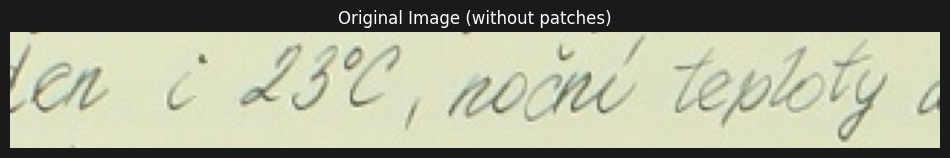

In [123]:
rand_idx = np.random.randint(len(grid_dataset))

image1 = grid_dataset.get_original_image1(rand_idx)
image1_patches, _, _ = grid_dataset[rand_idx]

print("Image1 shape:", image1.shape)
print("Image1 patches shape:", image1_patches.shape)

show_image(image1)

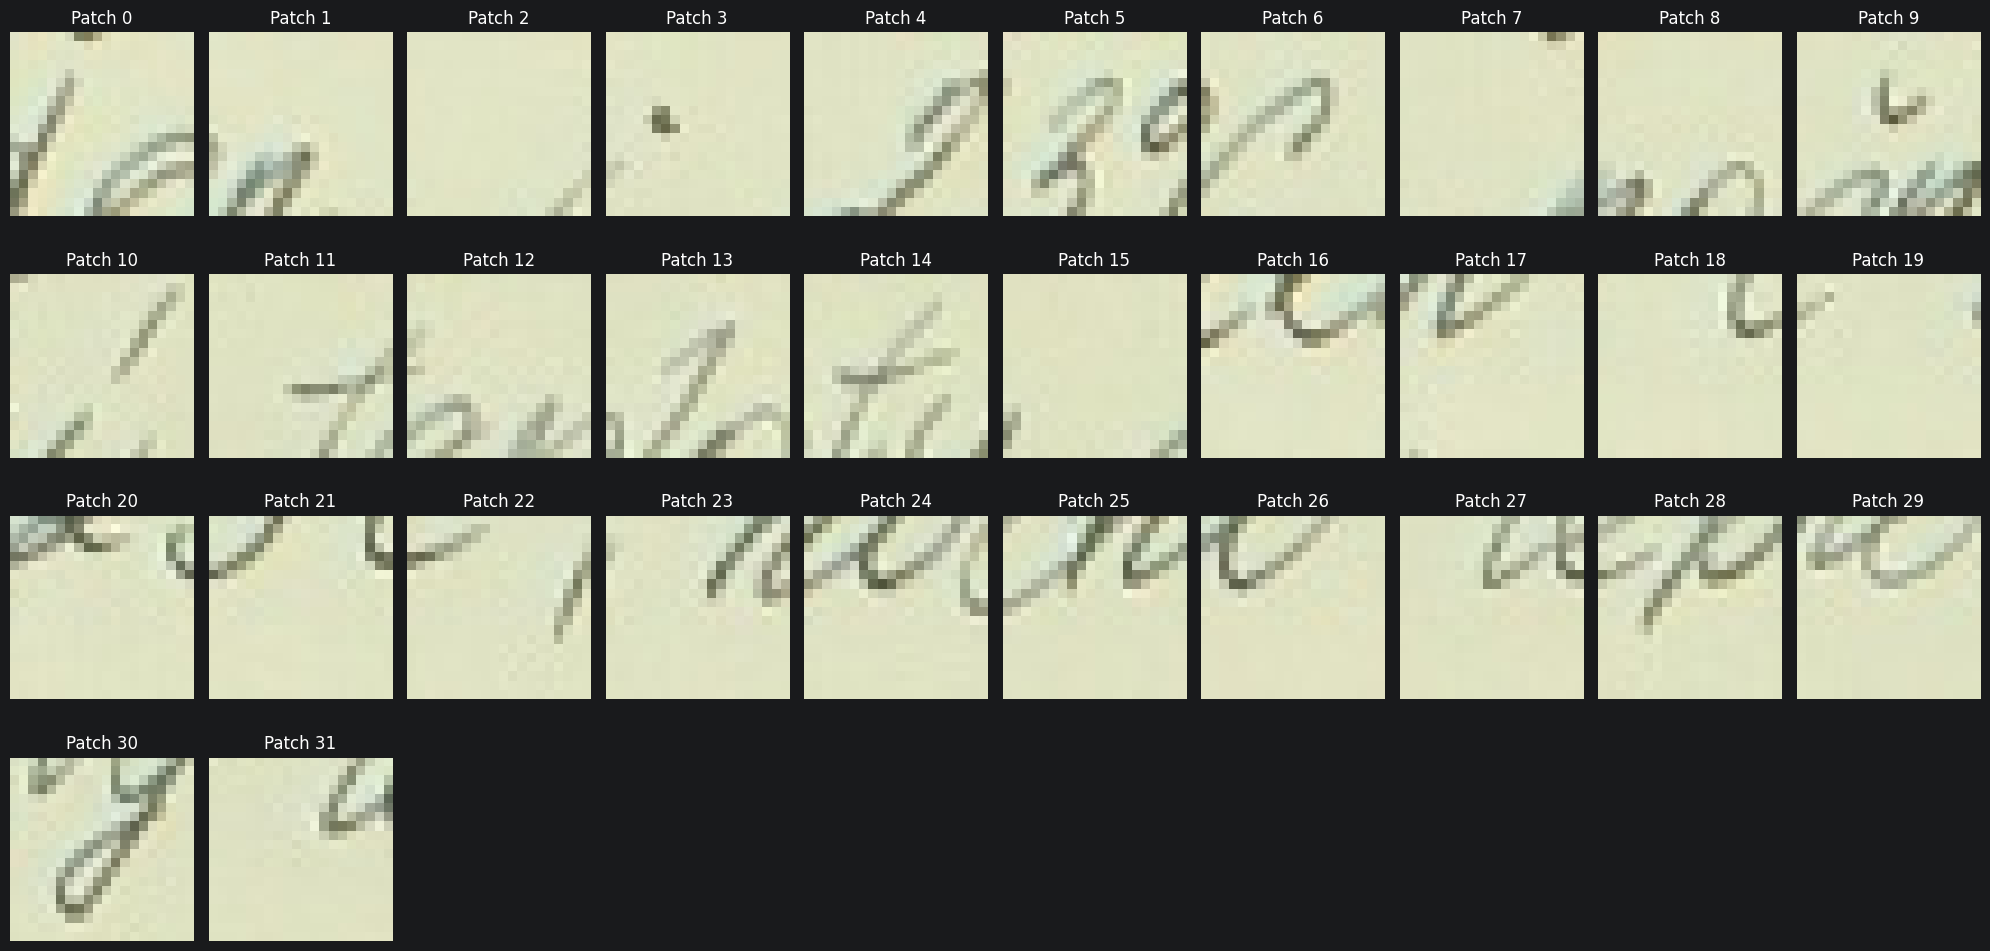

In [124]:
show_patches(image1_patches, cols=10)

torch.Size([15, 32, 3, 20, 20]) torch.Size([15, 32, 3, 20, 20])
torch.Size([15, 32]) torch.Size([15, 32])
torch.Size([15])


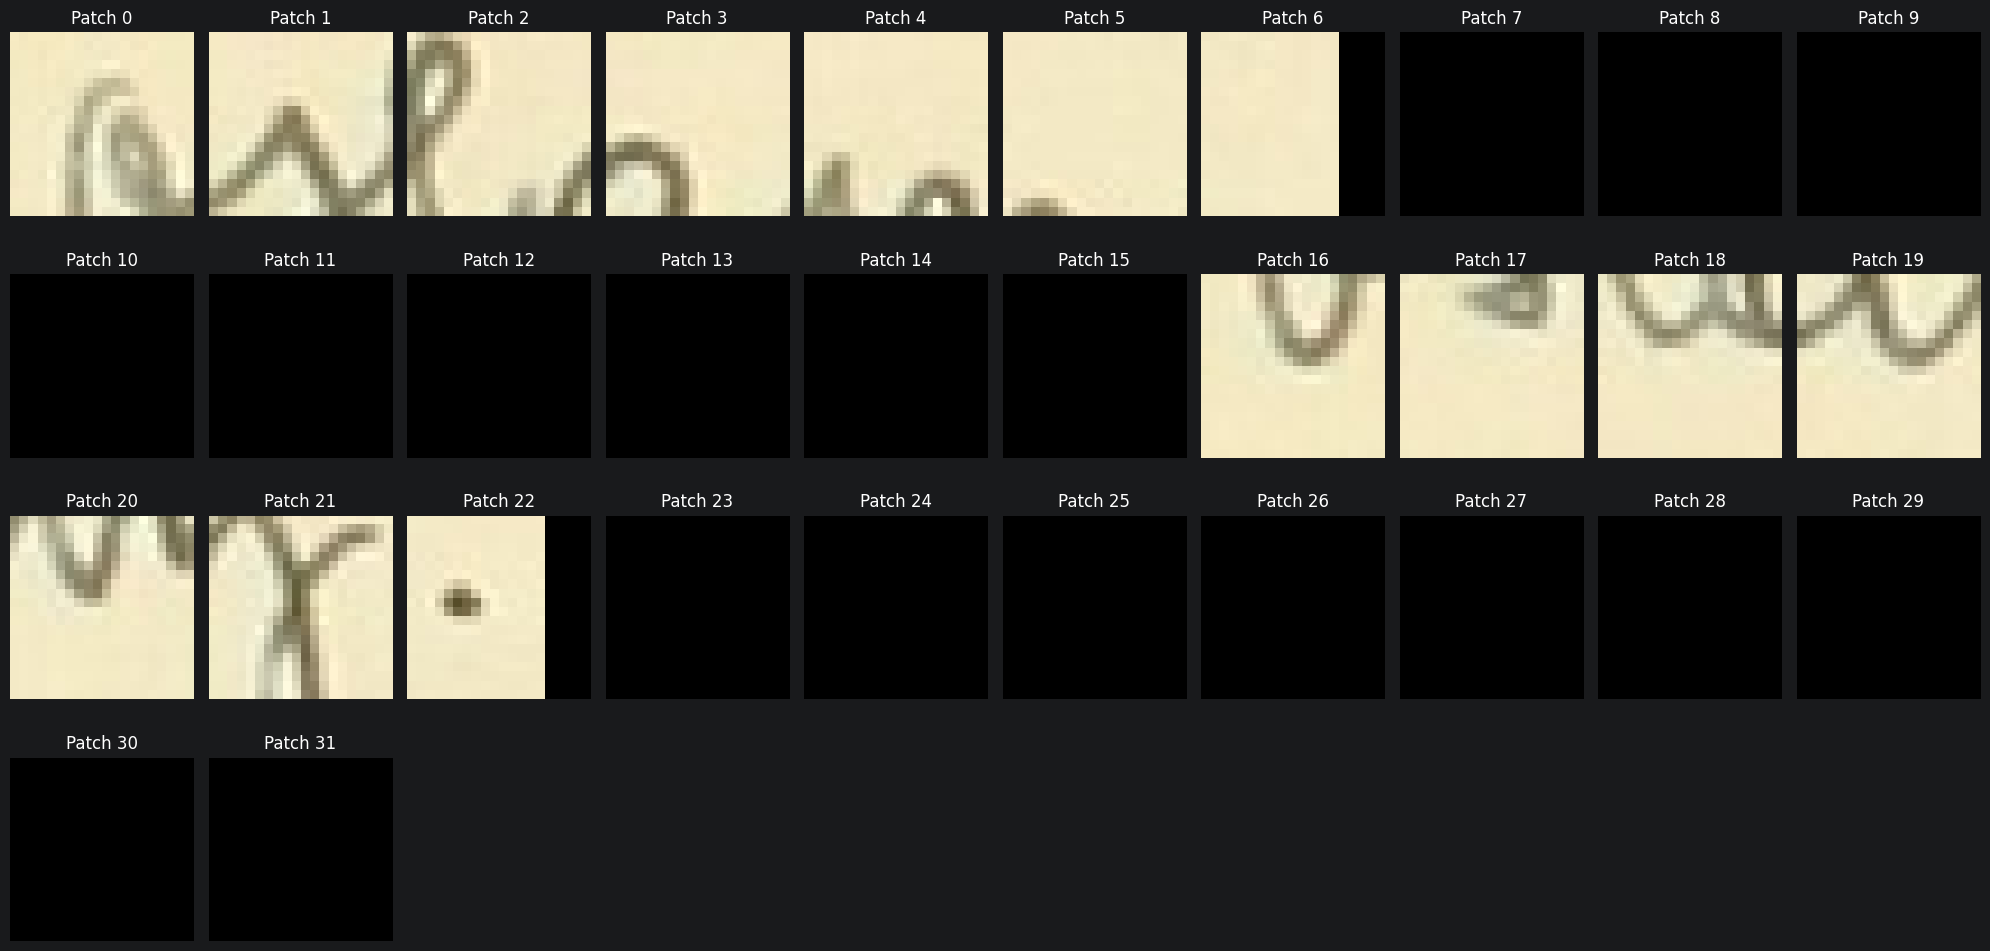

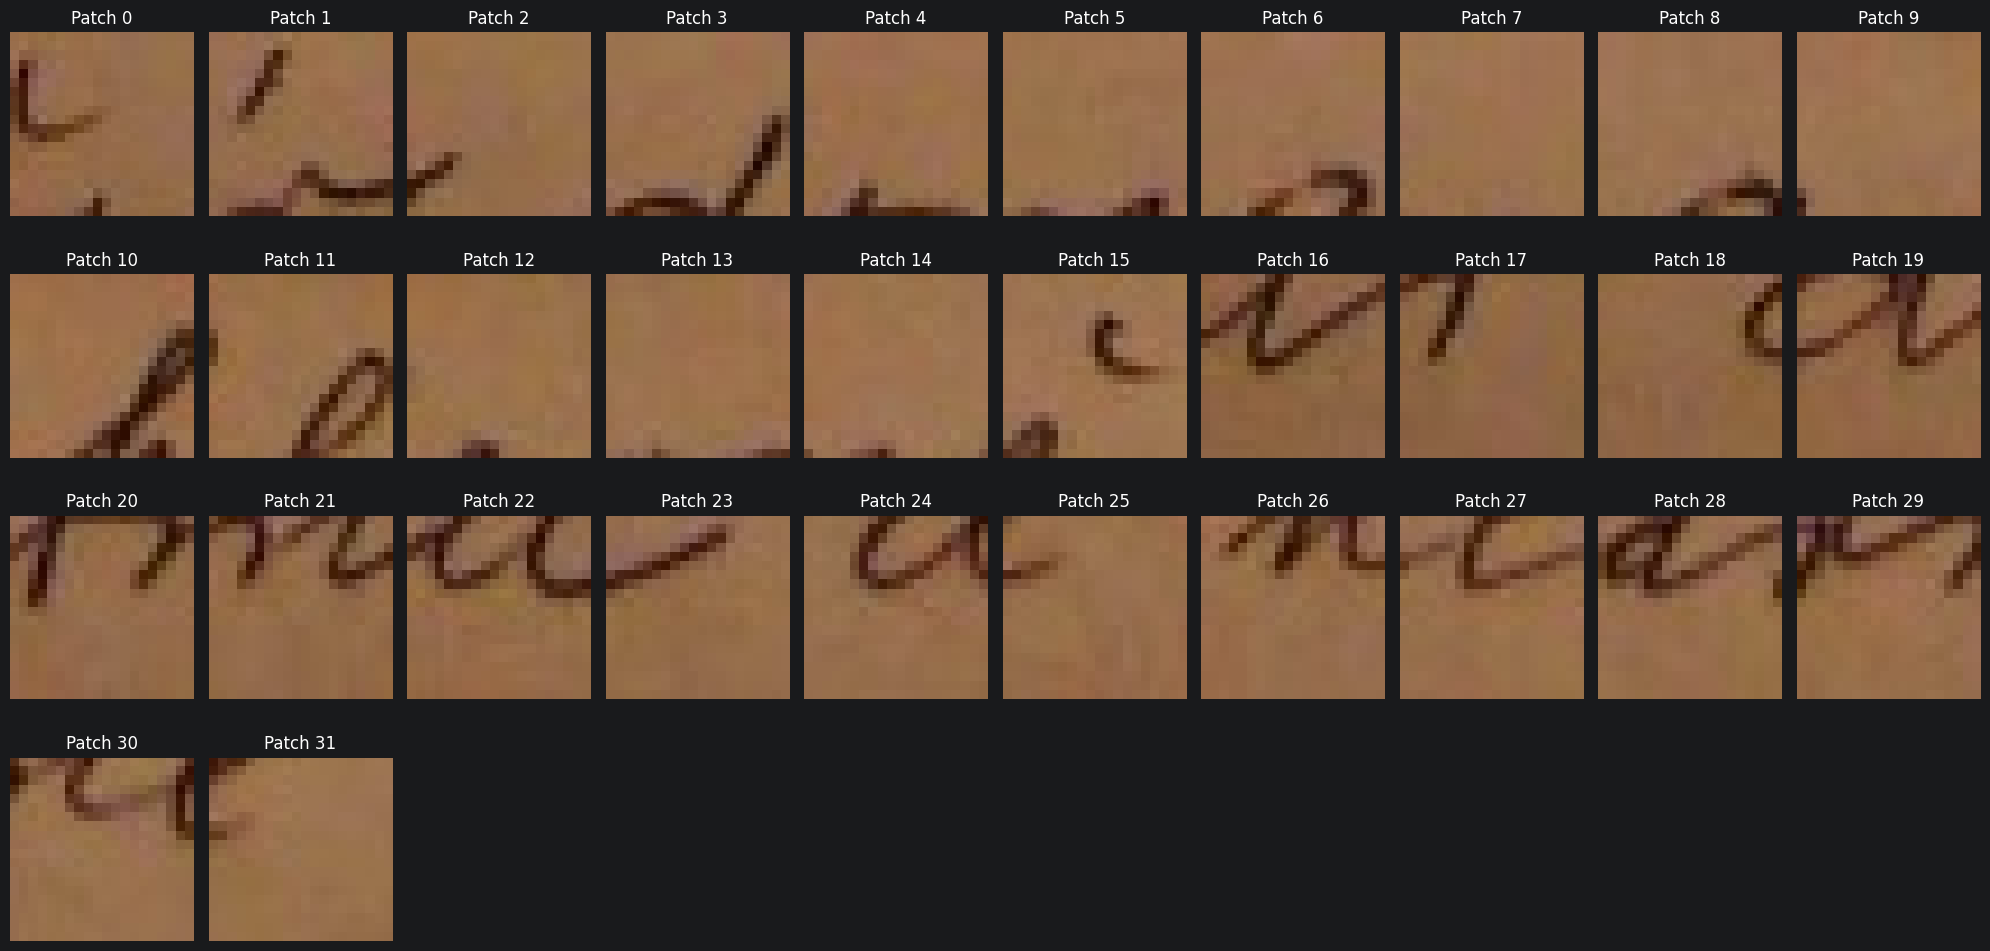

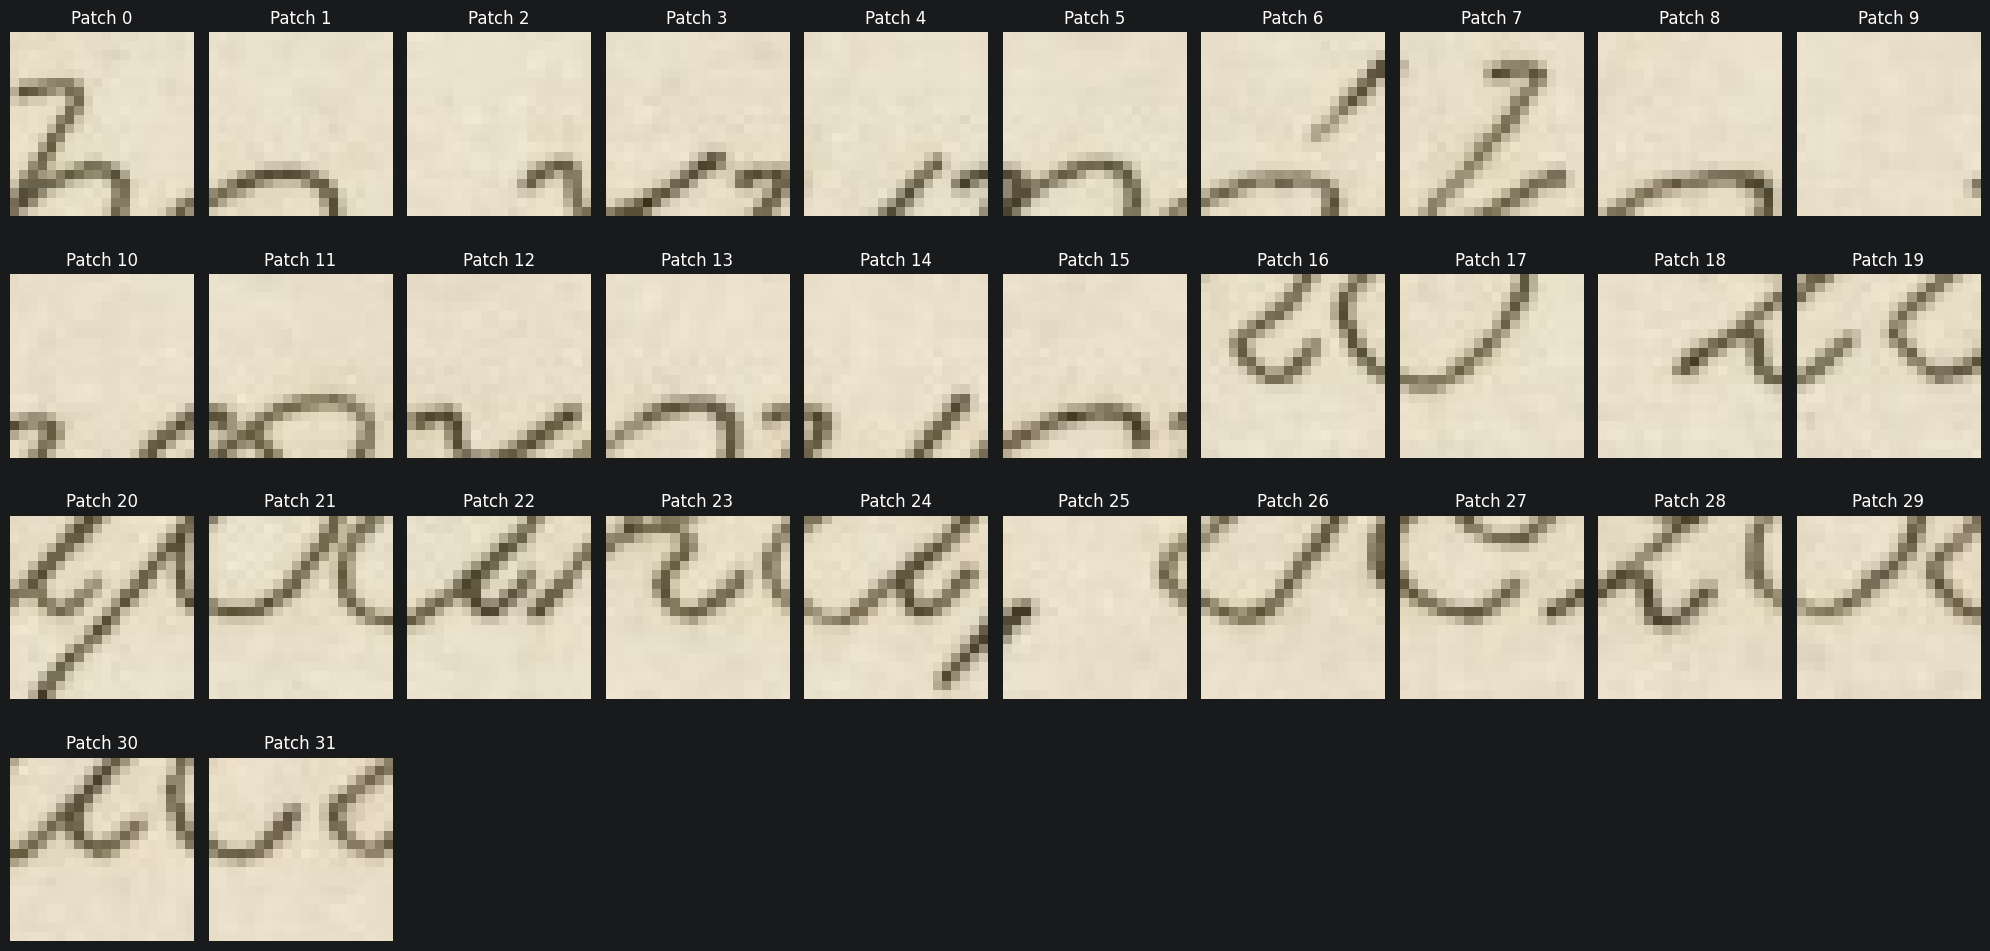

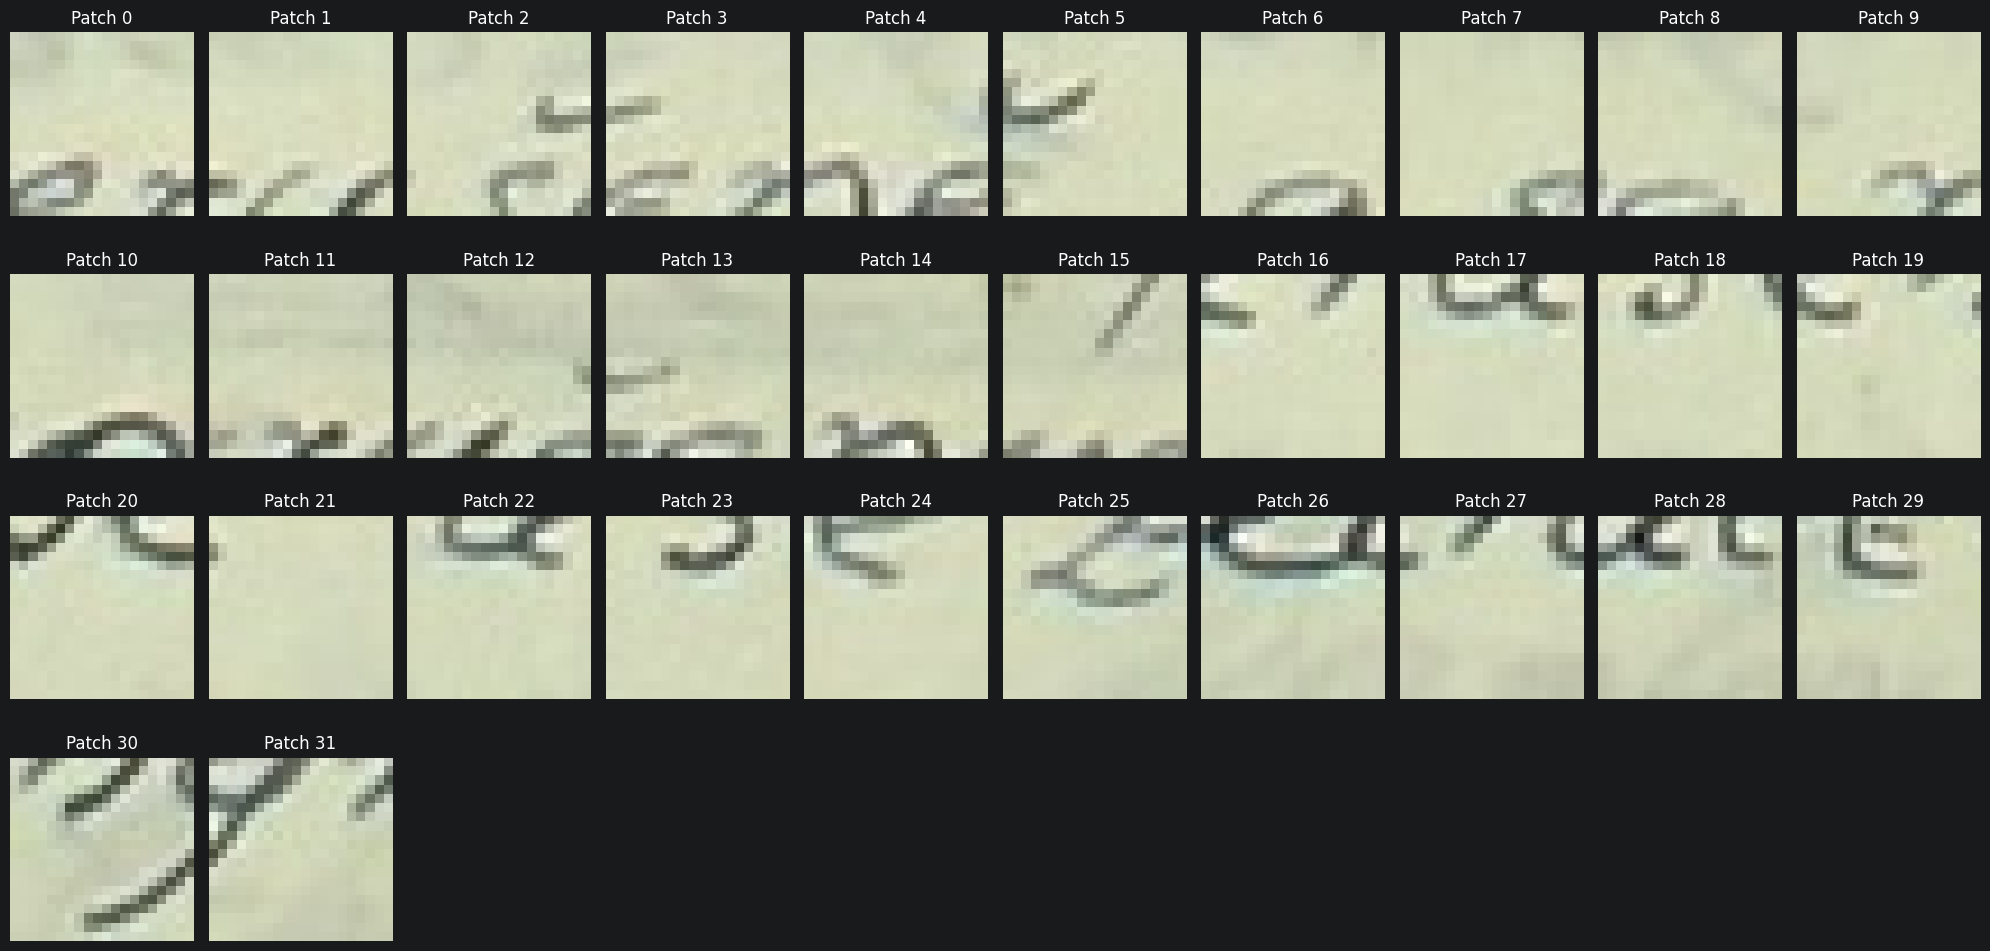

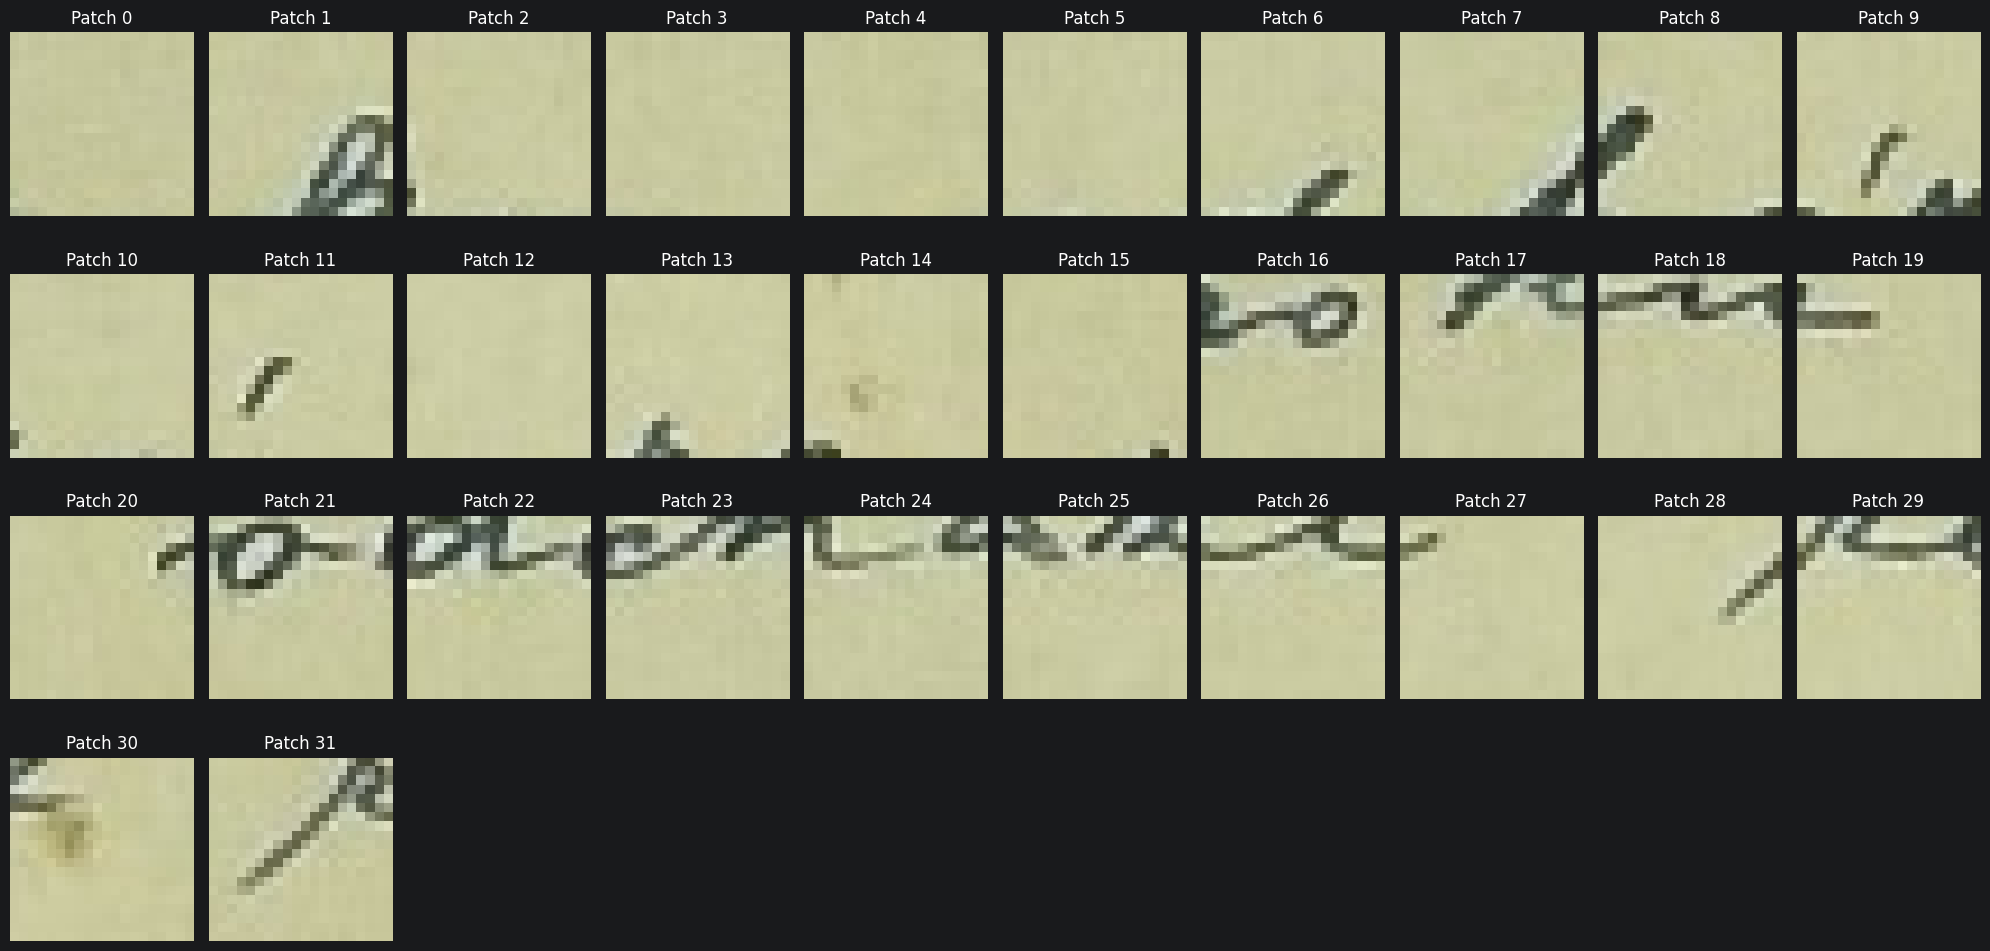

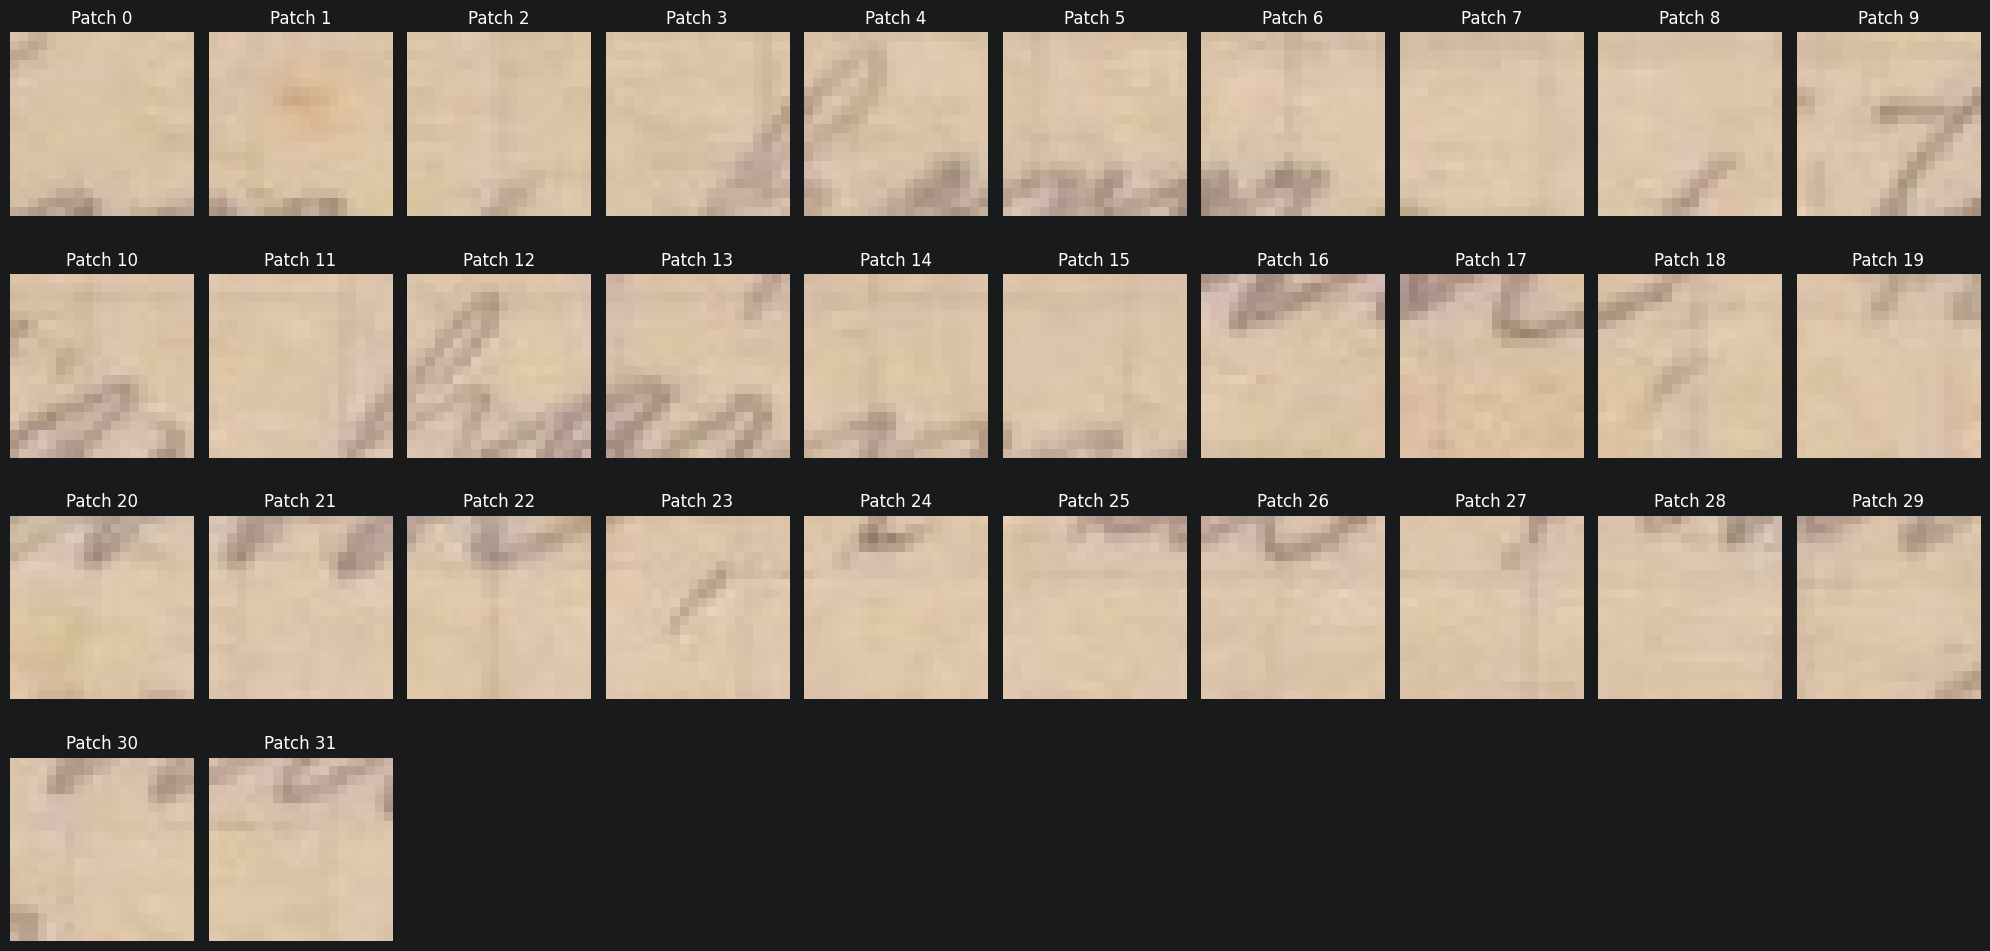

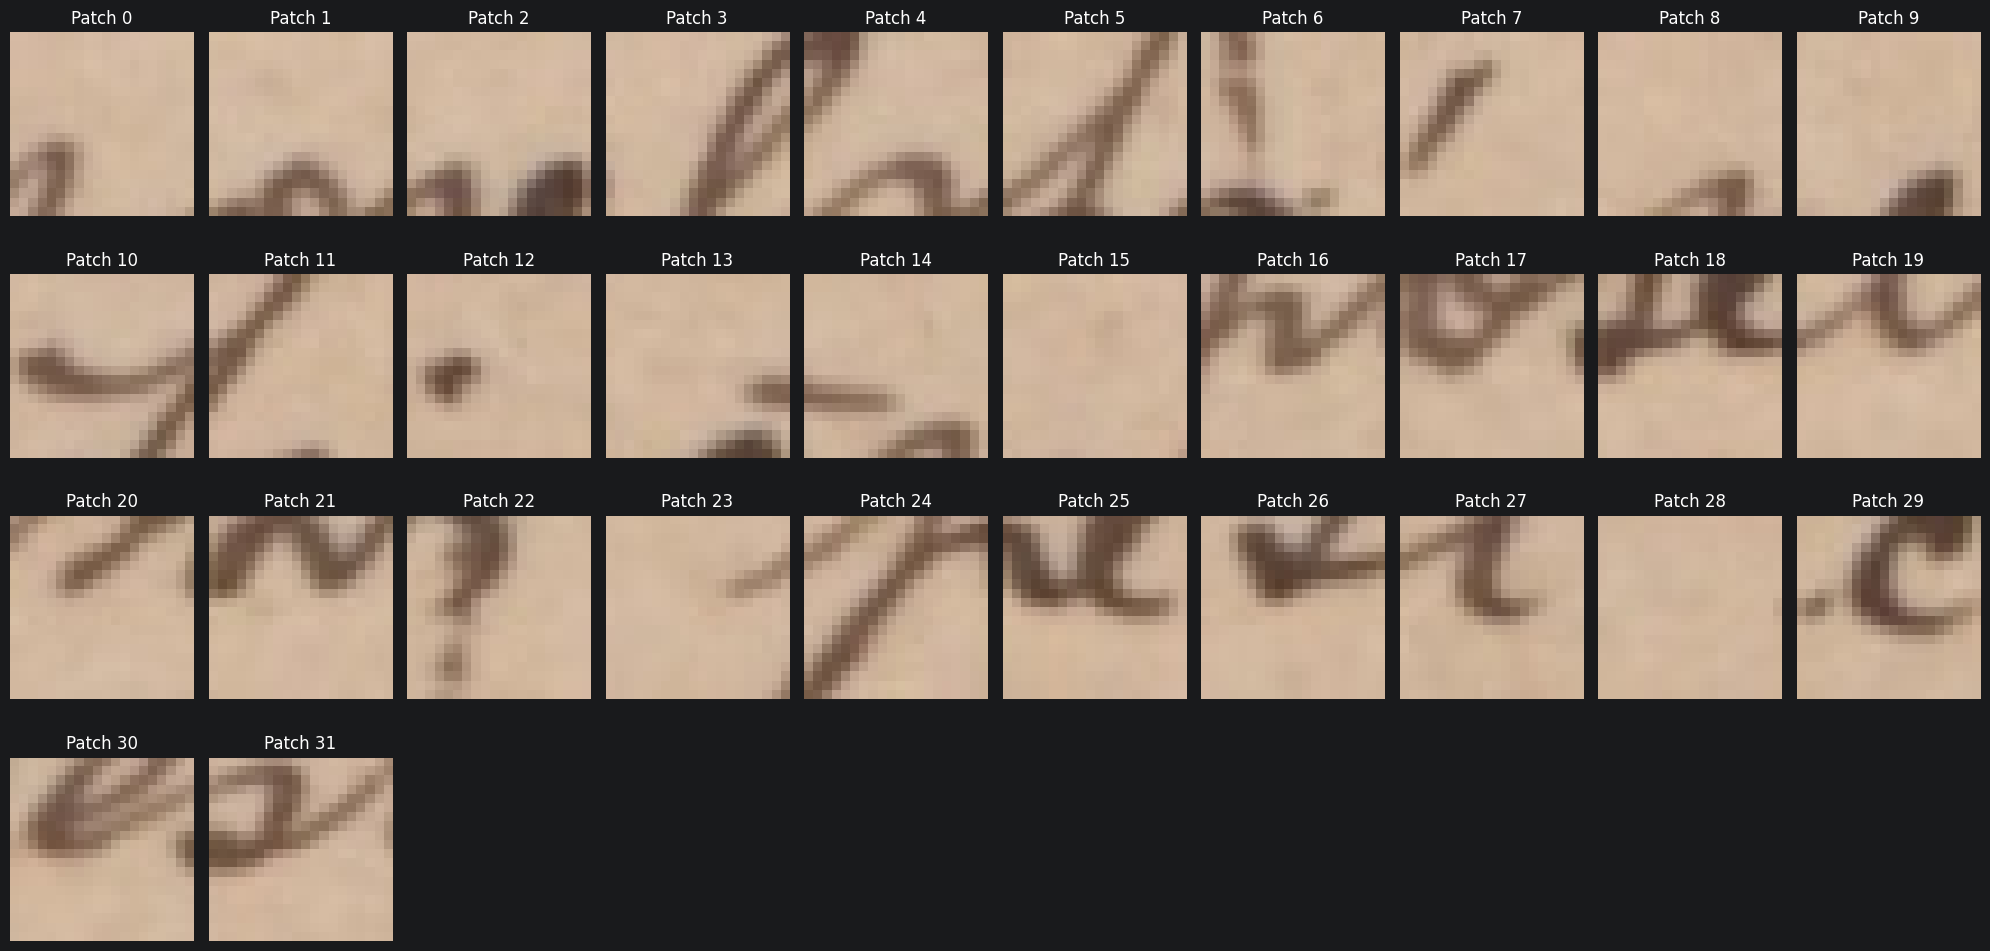

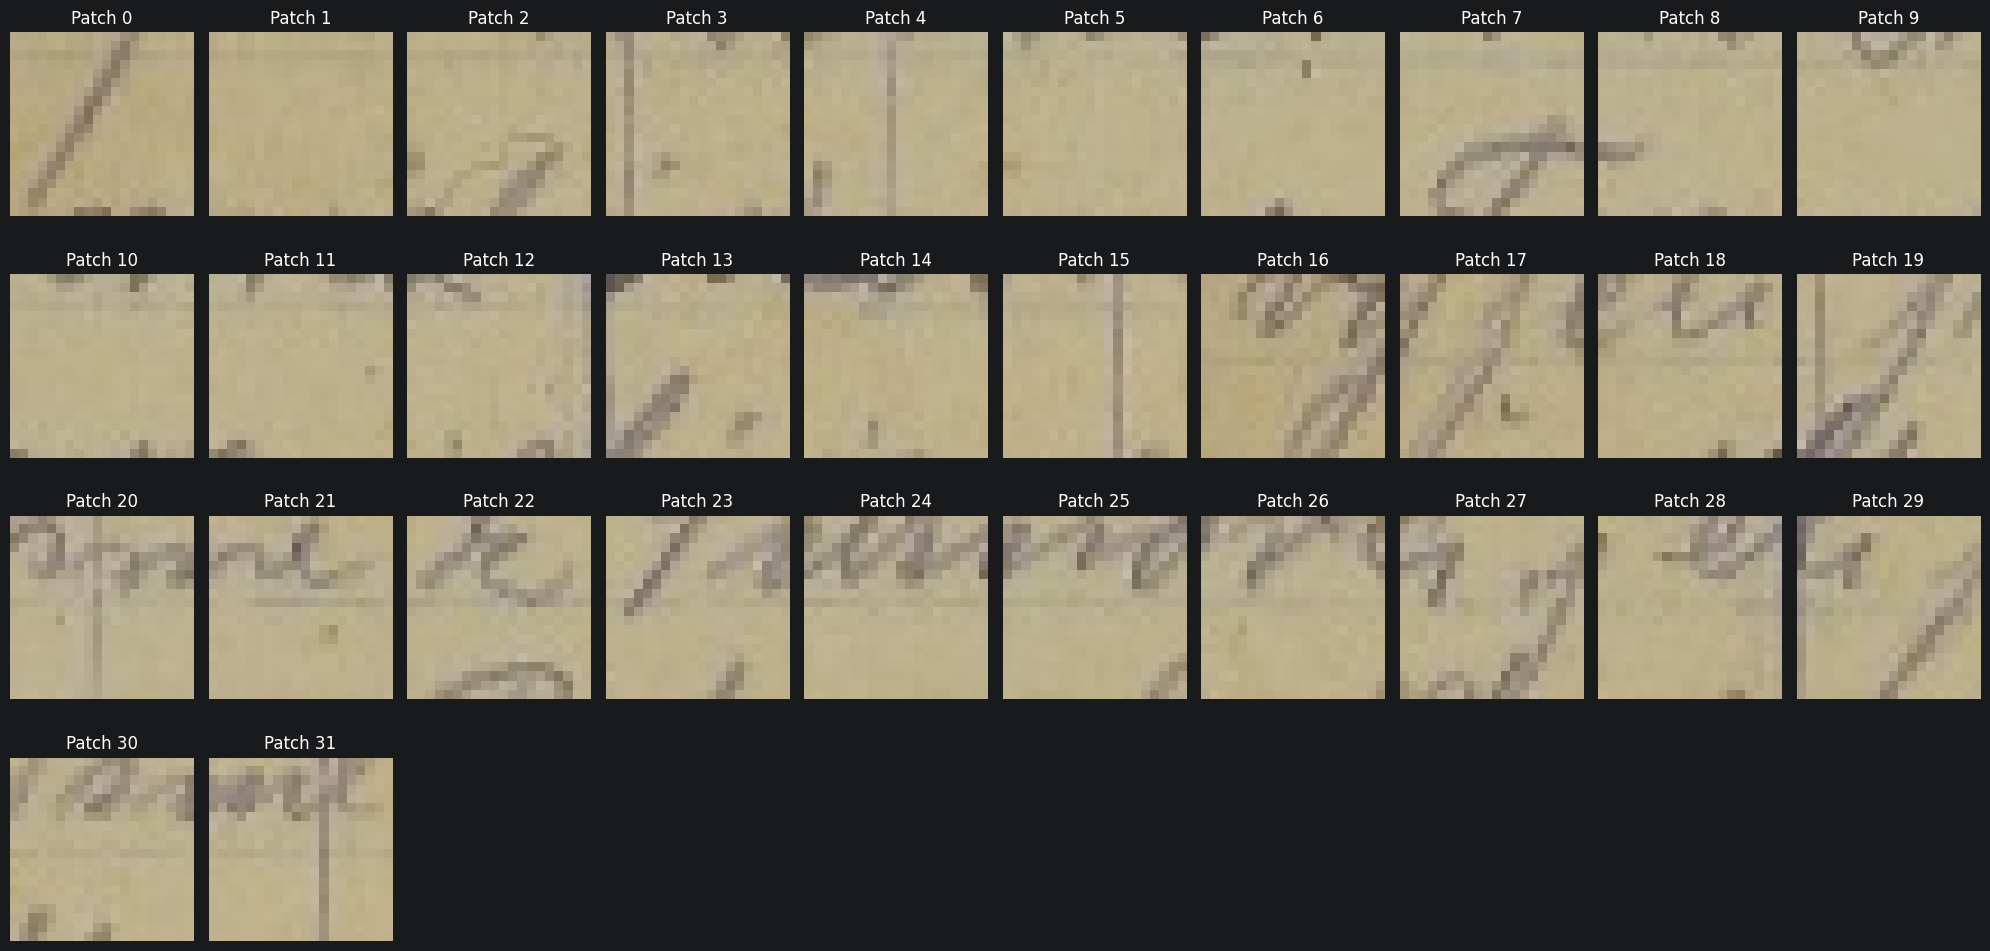

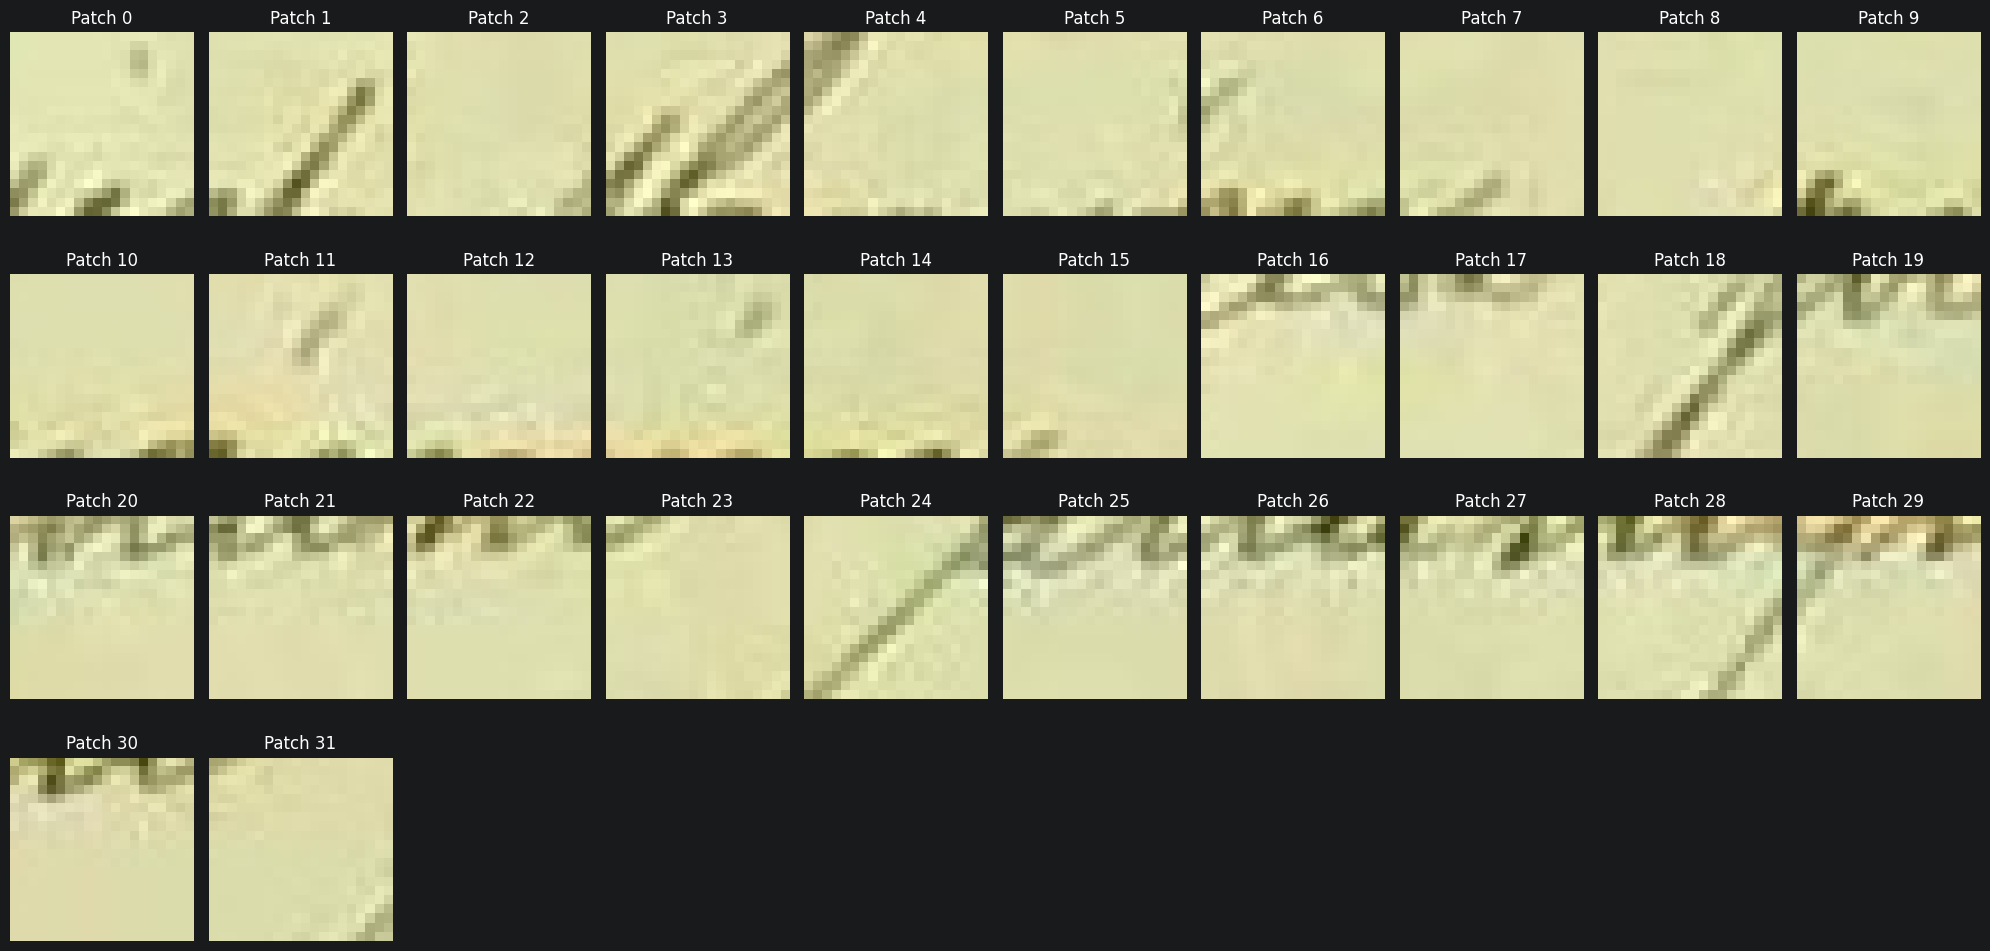

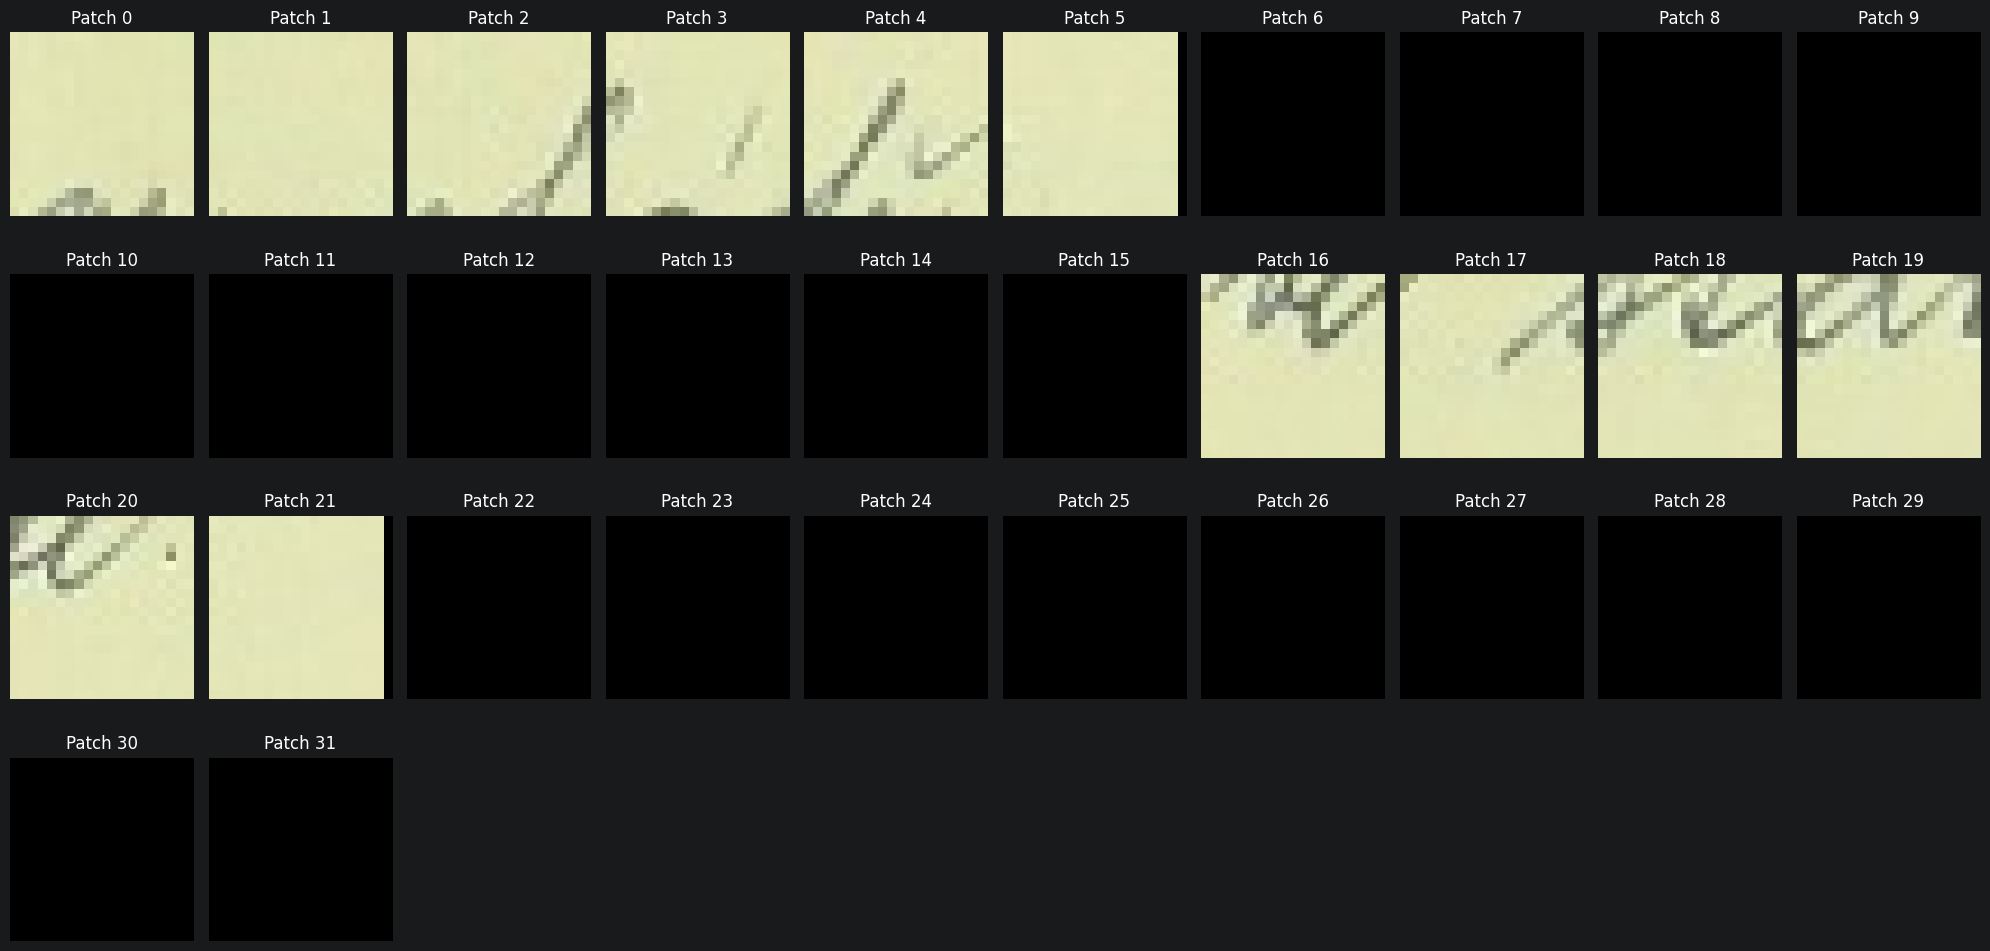

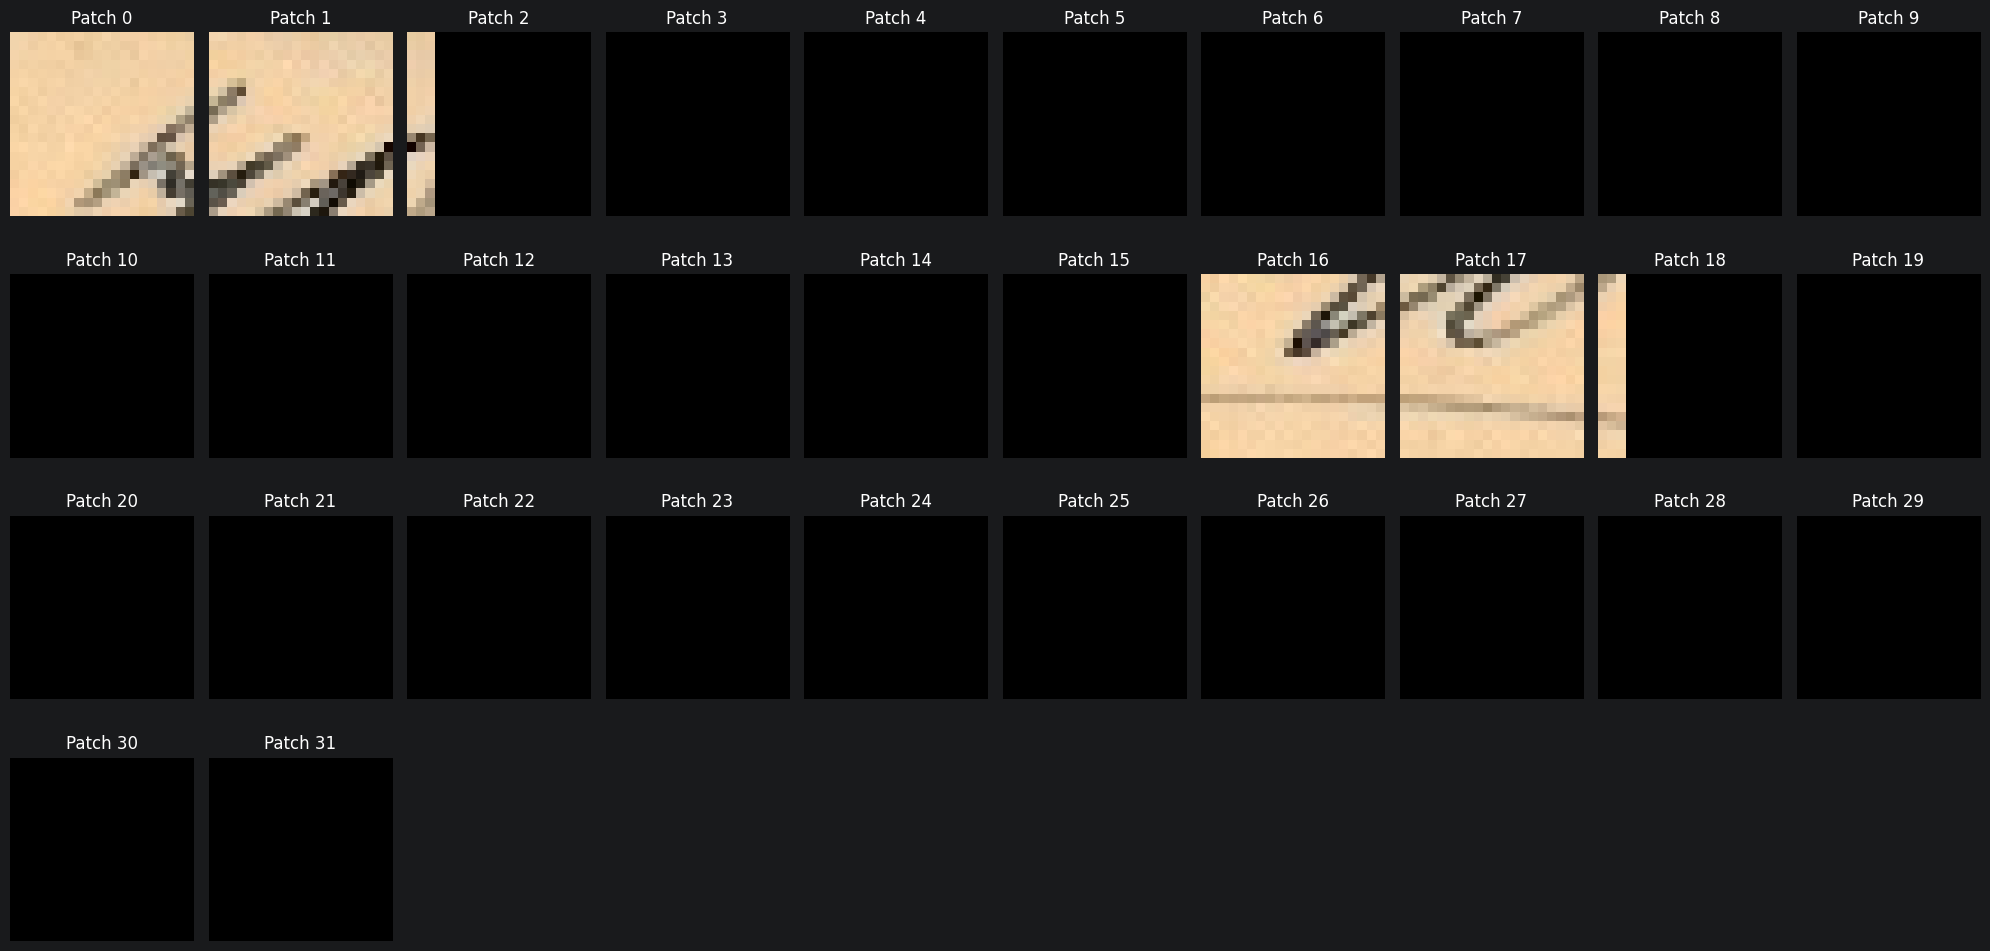

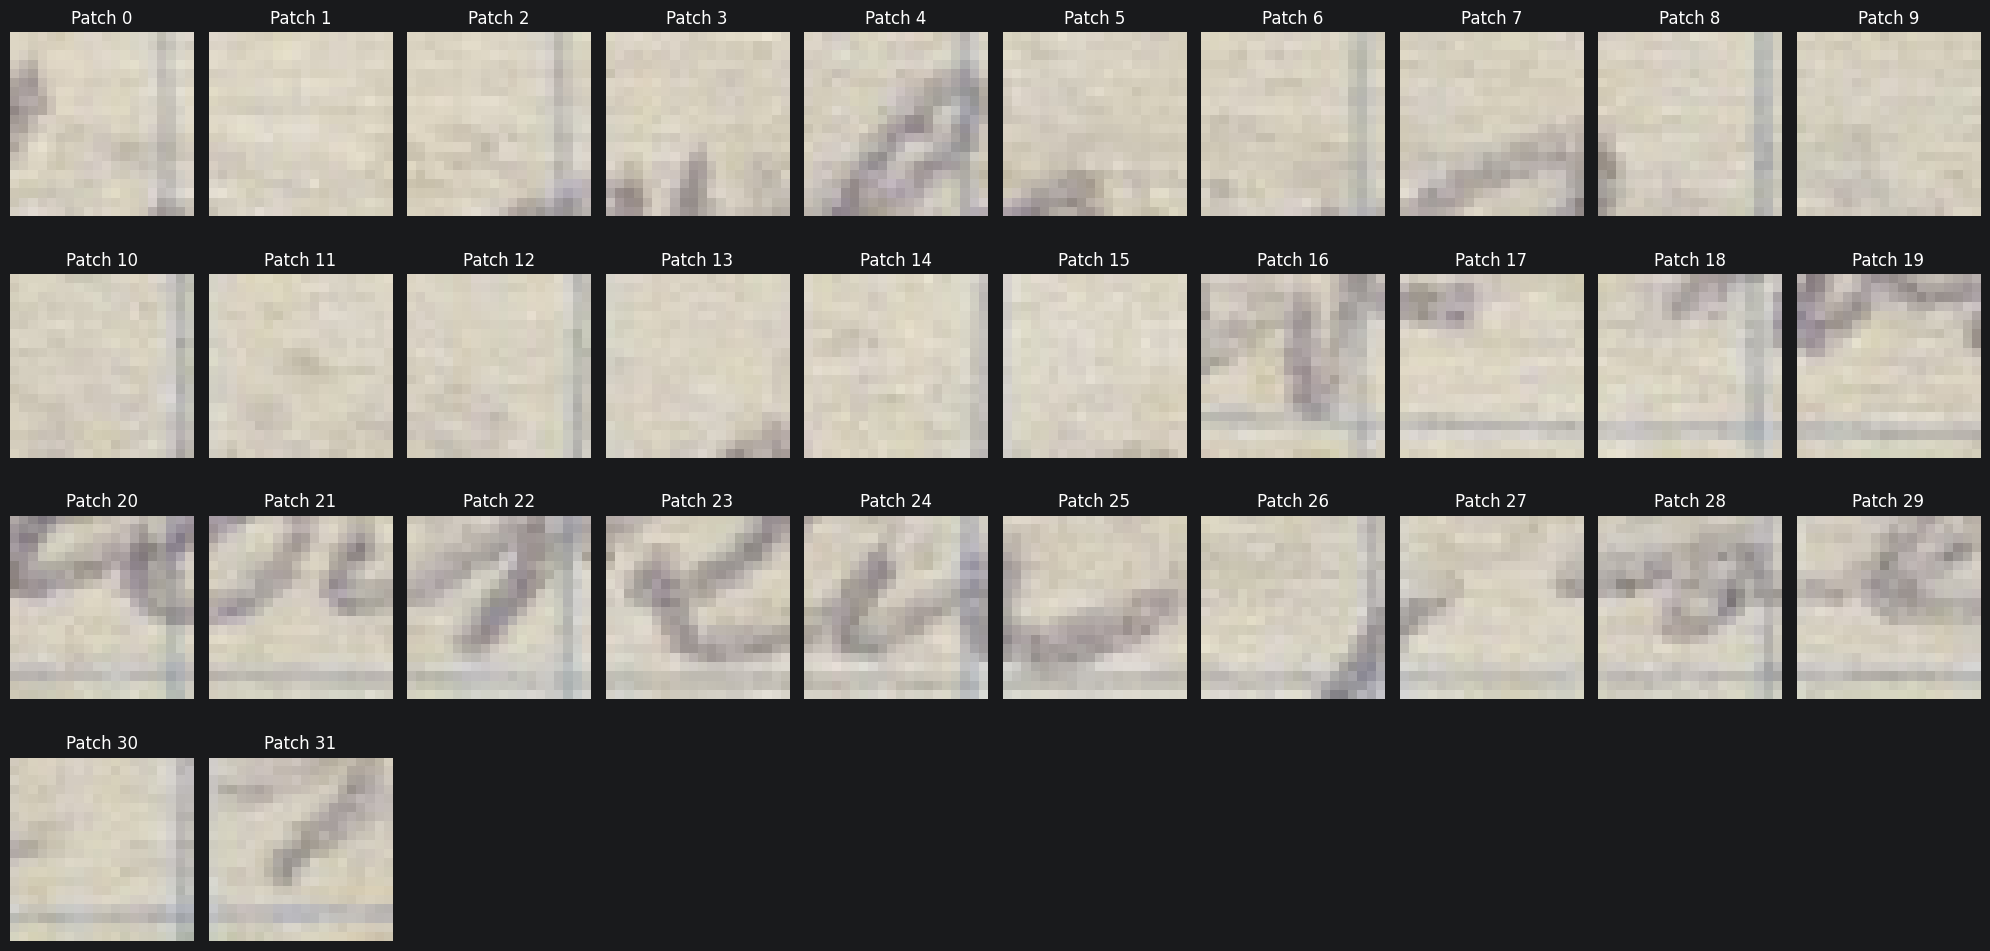

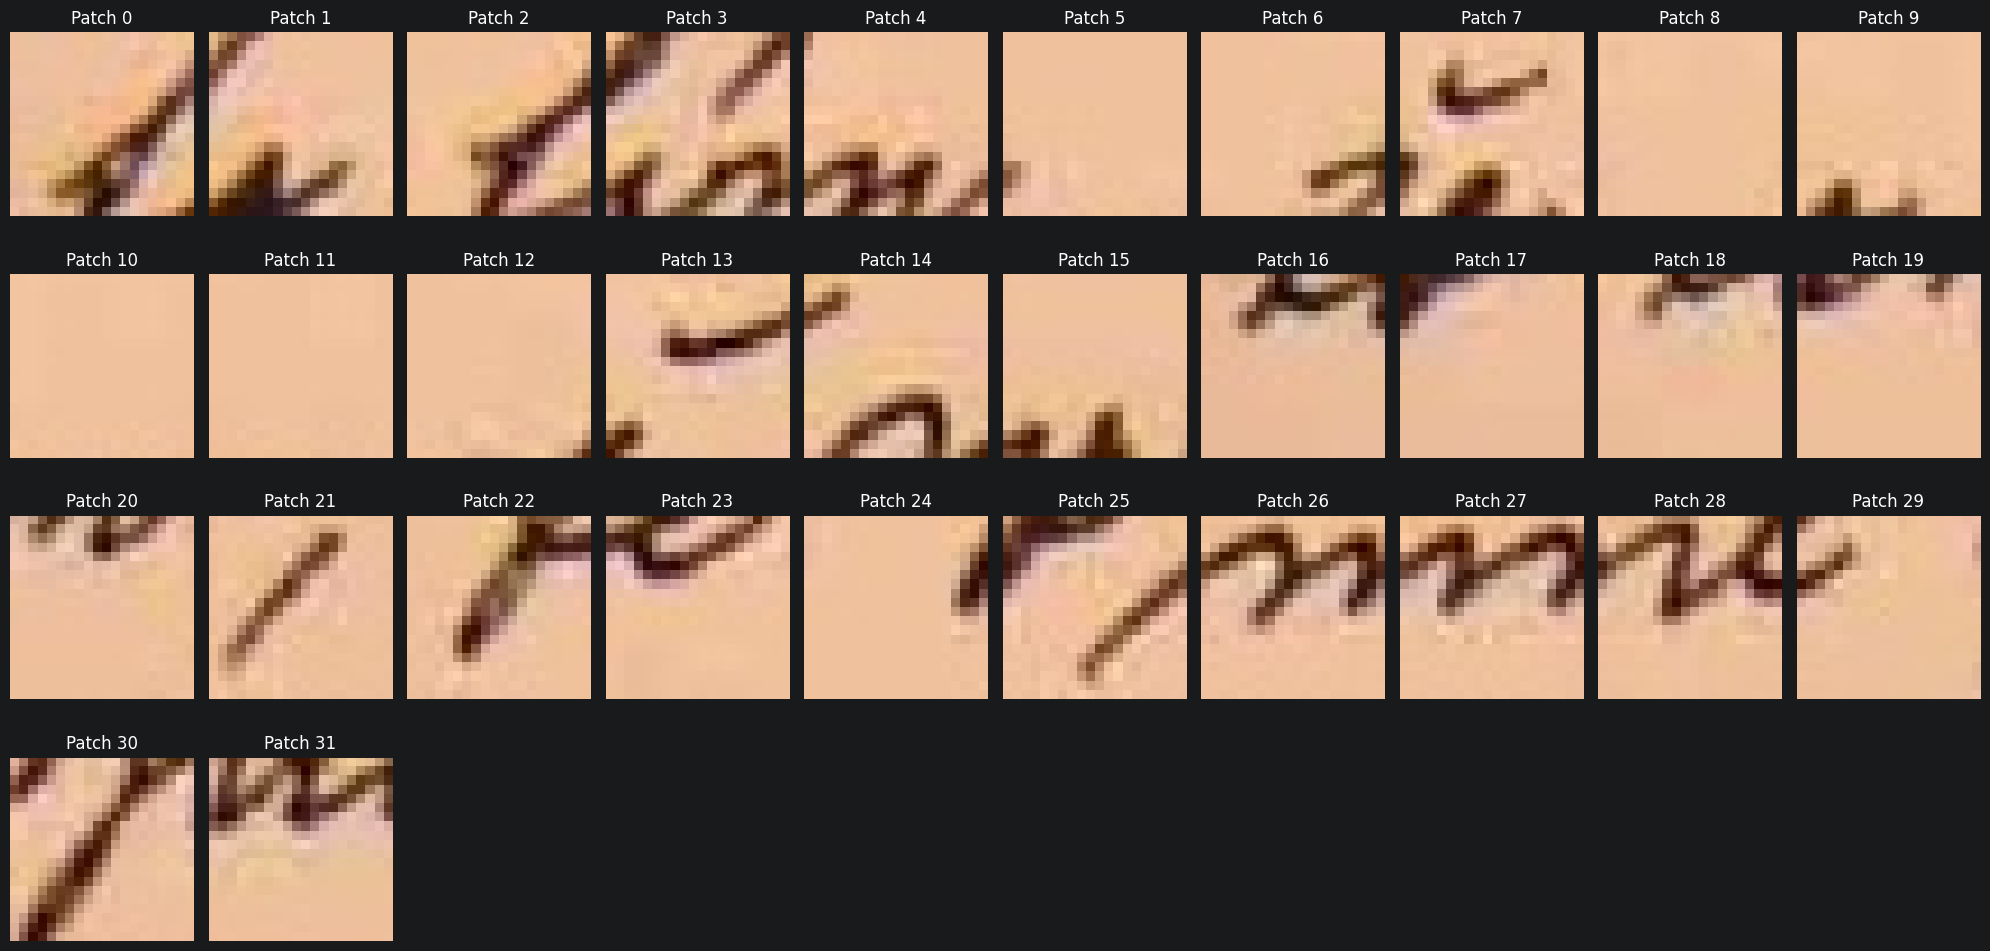

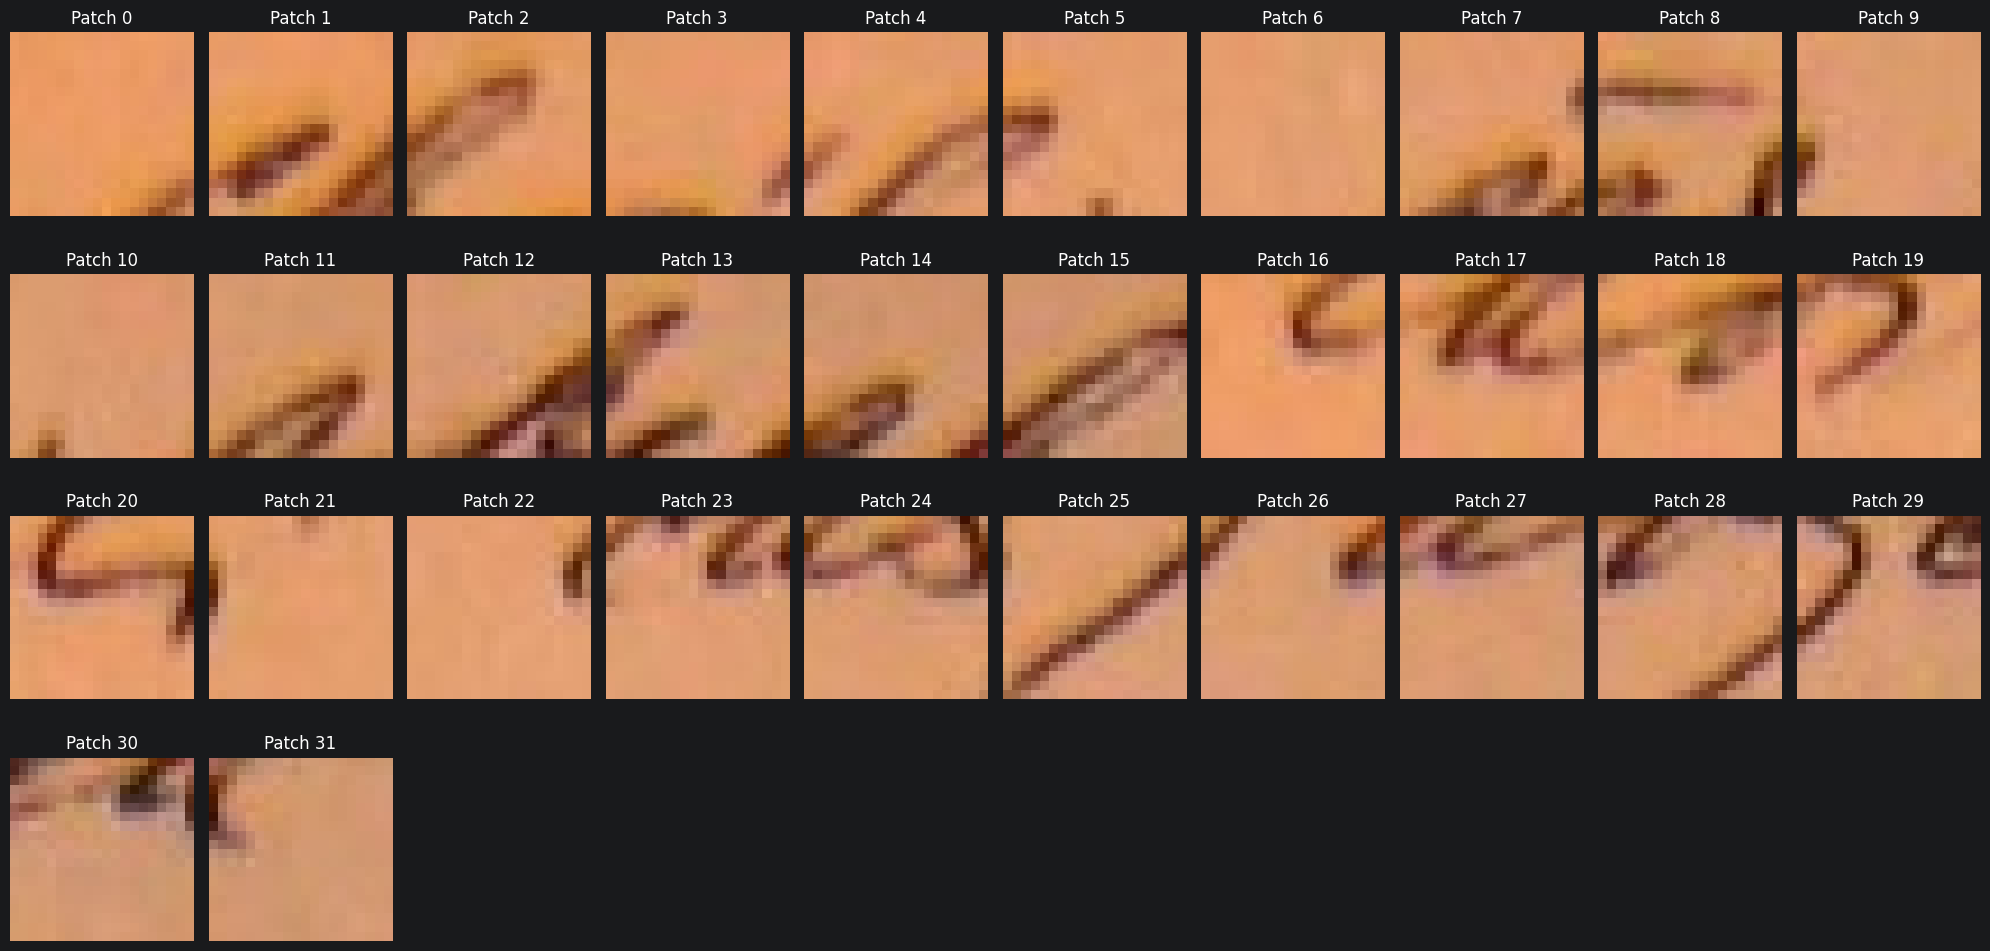

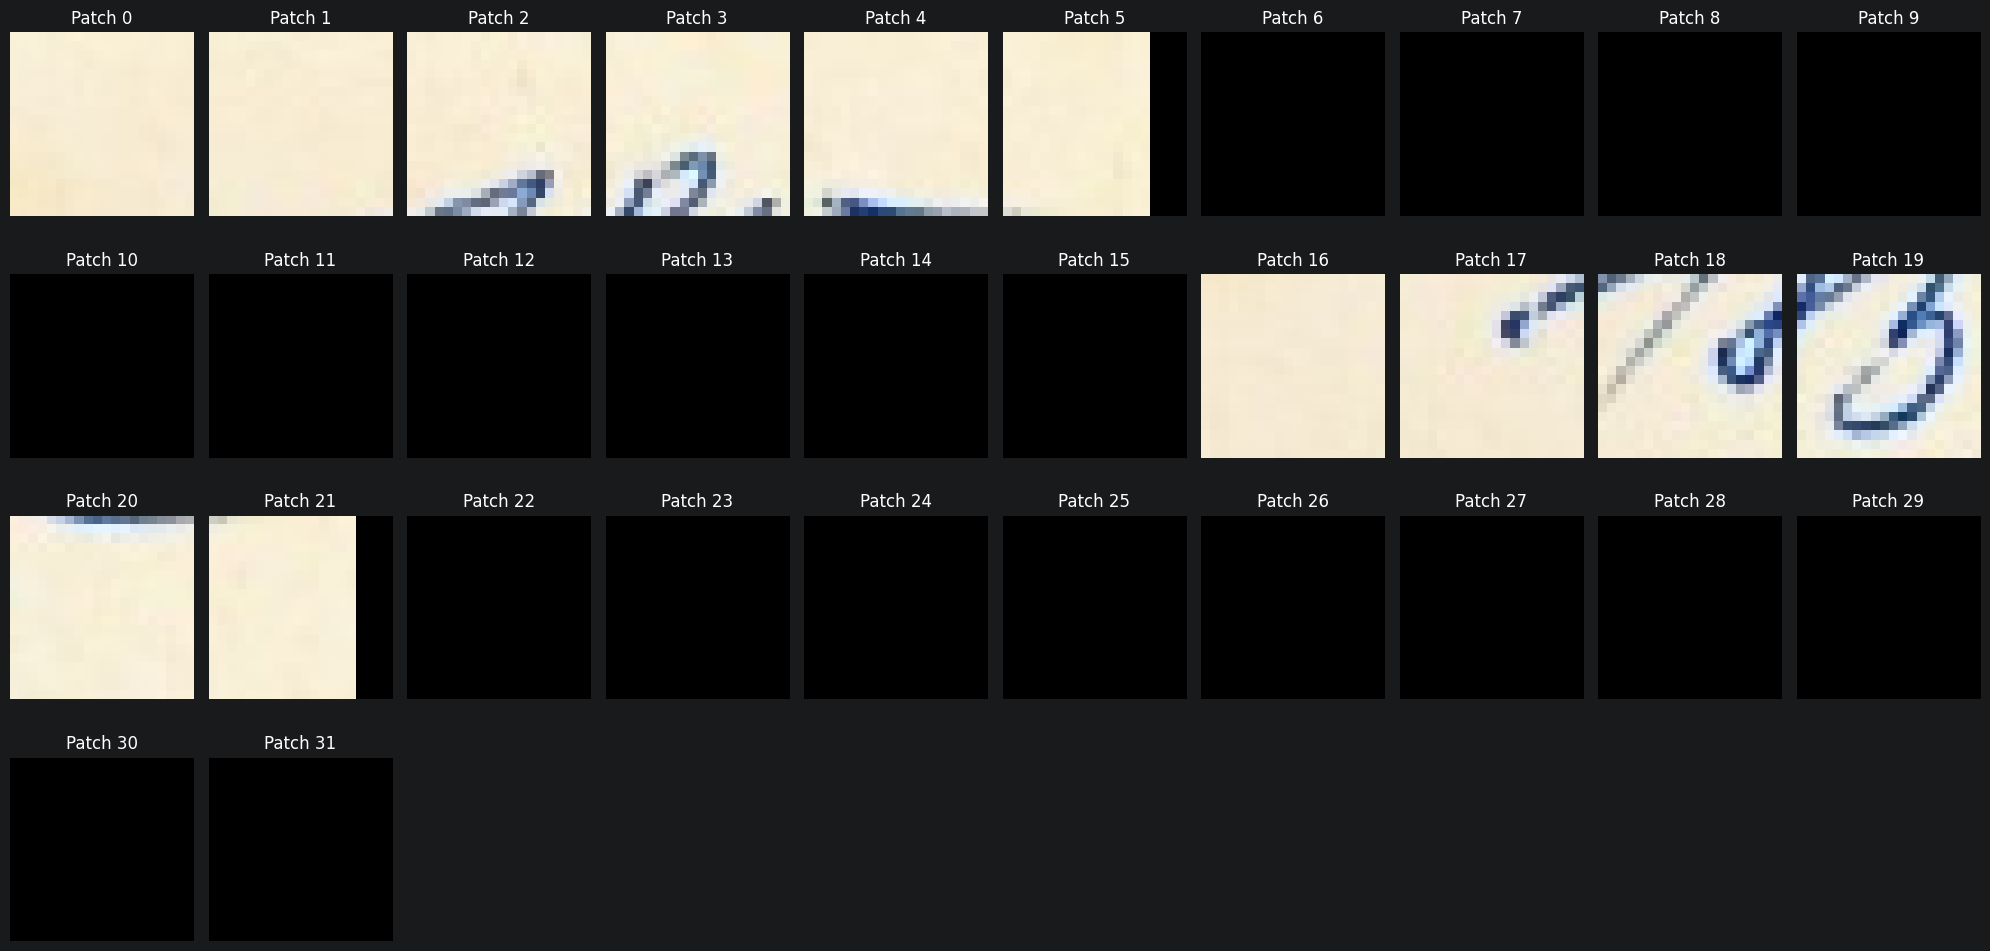

In [125]:
i = 0

for batch in grid_dataloader:

    if len(batch) == 5:
        images_1, images_2, labels, mask_1, mask_2 = batch
    else:
        continue

    print(images_1.shape, images_2.shape)
    print(mask_1.shape, mask_2.shape)
    print(labels.shape)

    for image_1 in images_1:
        show_patches(image_1, cols=10)

    if i == 0:
        break

    i += 1

Image1 shape: torch.Size([3, 40, 320])
Image1 patches shape: torch.Size([50, 3, 15, 15])


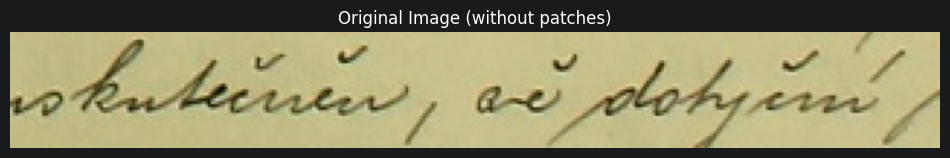

In [9]:
rand_idx = np.random.randint(len(random_dataset))

image1 = random_dataset.get_original_image1(rand_idx)
image1_patches, _, _ = random_dataset[rand_idx]

print("Image1 shape:", image1.shape)
print("Image1 patches shape:", image1_patches.shape)

show_image(image1)

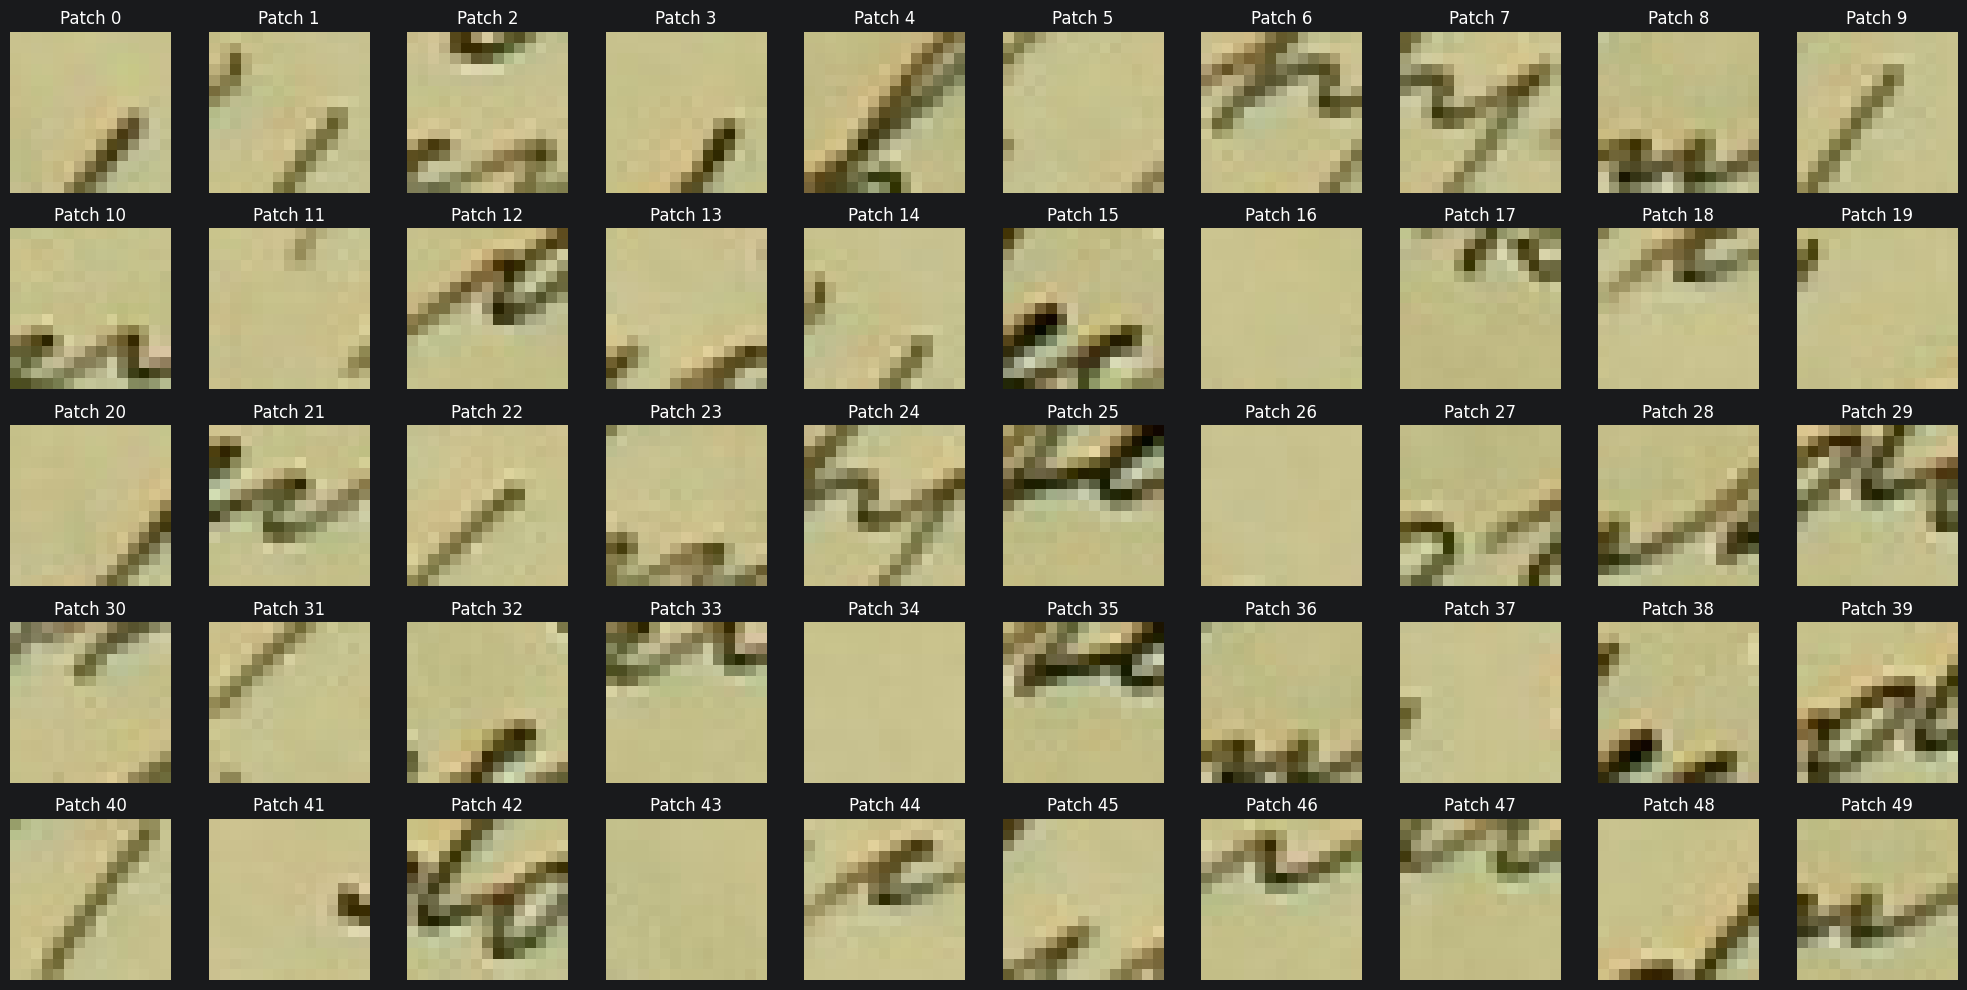

In [10]:
show_patches(image1_patches, cols=10)

Image1 shape: torch.Size([3, 40, 320])
Image1 patches shape: torch.Size([50, 3, 15, 15])


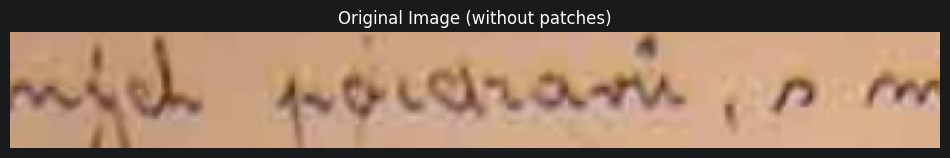

In [11]:
rand_idx = np.random.randint(len(sift_dataset))

image1 = sift_dataset.get_original_image1(rand_idx)
image1_patches, _, _ = sift_dataset[rand_idx]

print("Image1 shape:", image1.shape)
print("Image1 patches shape:", image1_patches.shape)

show_image(image1)

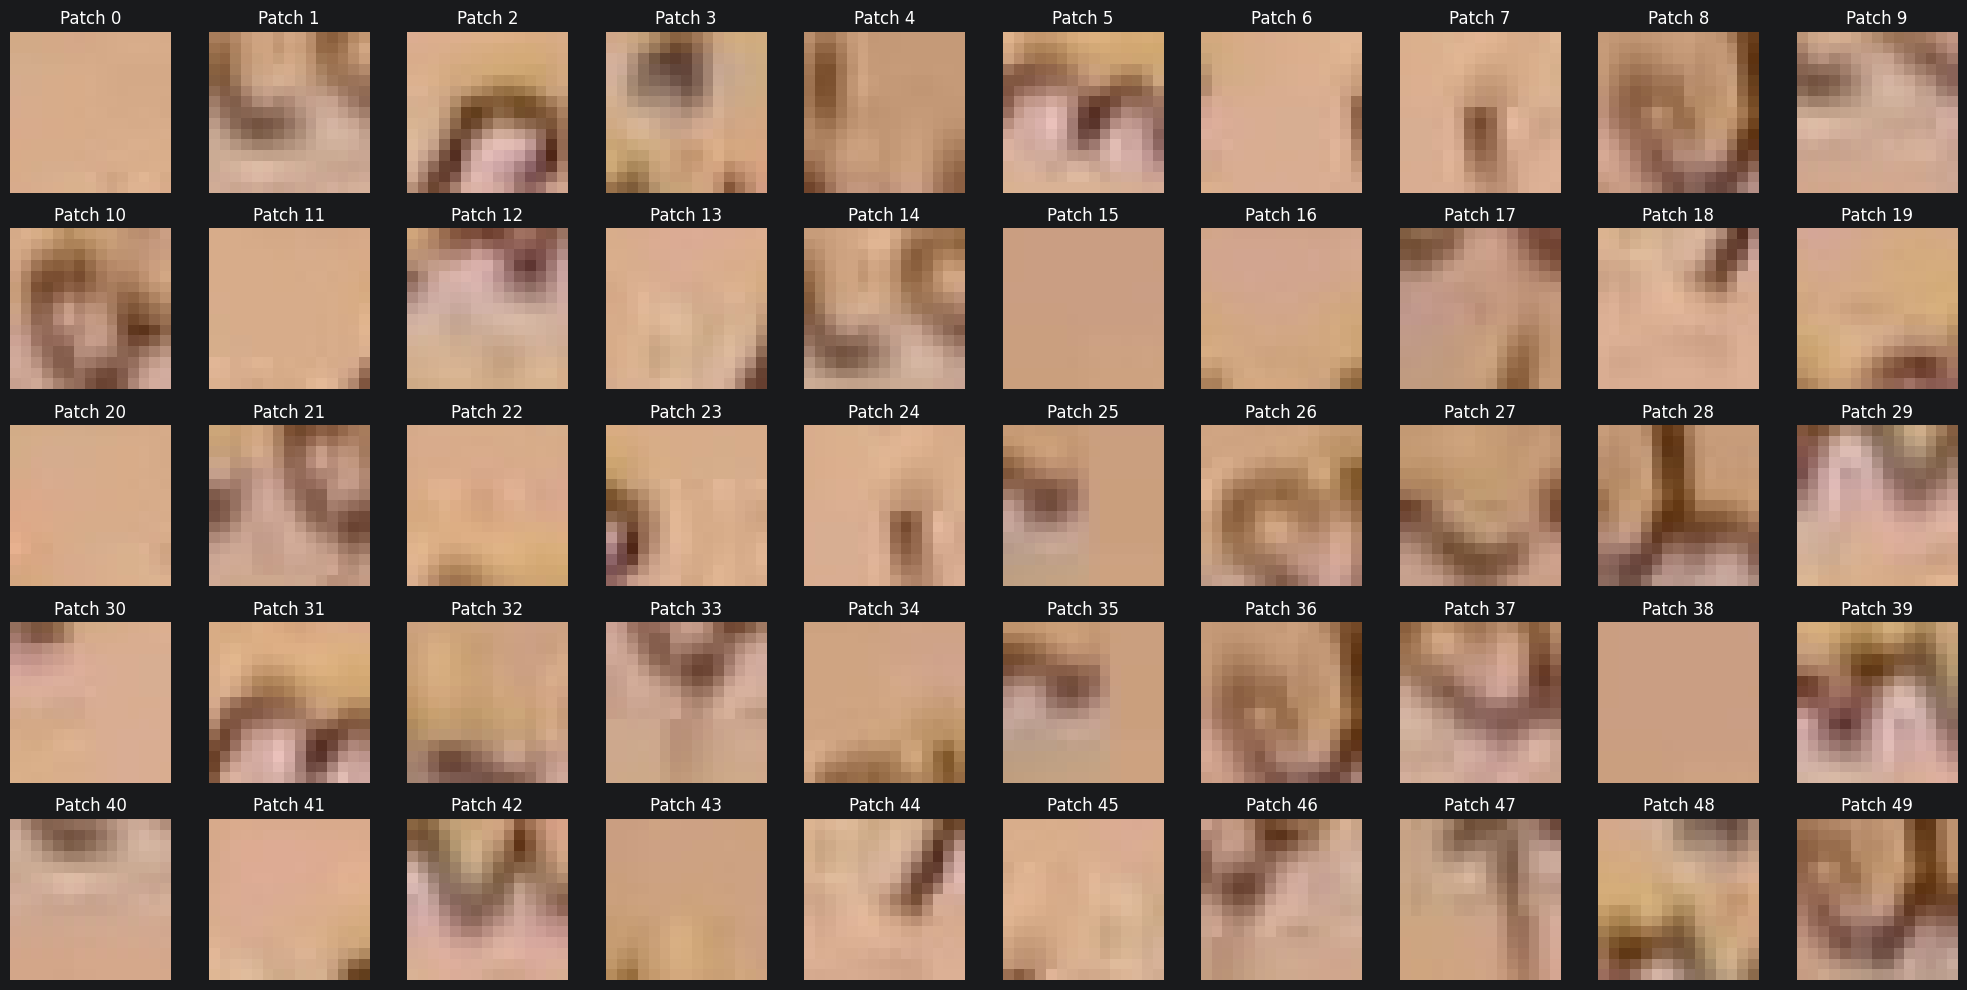

In [12]:
show_patches(image1_patches, cols=10)